SAHAN TEST 10 Students

In [9]:
# %pip install statsmodels tqdm scikit-learn pandas numpy matplotlib seaborn joblib

In [10]:
# pip install tensorflow

In [11]:
# %pip uninstall -y numpy scikit-learn scipy joblib
# %pip cache purge


In [12]:
# %pip install scikit-learn==1.4.2


In [13]:
import numpy, sklearn
print(numpy.__version__)
print(sklearn.__version__)


2.0.2
1.6.1


In [14]:
# %%
# 1) Imports and constants
import os, math, random
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from tqdm import tqdm

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# File paths & hyperparams (change as needed)
DATA_PATH = "/content/student_multi_10profiles_fullclasses_2015_2025.csv"
OUTPUT_DIR = "newdata/forecast_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_DIR = os.path.join(OUTPUT_DIR, "per_student_models")
os.makedirs(MODEL_DIR, exist_ok=True)

# Modeling hyperparameters
GLOBAL_LOOKBACK = 60      # days history for global model training
GLOBAL_HORIZON = 90       # 90 days = 3 months (set to 180 for 6 months)
PER_STUDENT_LOOKBACK = 60
PER_STUDENT_HORIZON = 90
MIN_HISTORY_DAYS = 200    # minimum daily records to train per-student model (tune)
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
BATCH_SIZE = 32
EPOCHS_GLOBAL = 30
EPOCHS_STUDENT = 50
print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [15]:
import os
print(os.getcwd())


/content


In [16]:
# %%
# 2) Load CSV and quick inspect
assert os.path.exists(DATA_PATH), f"Data file not found: {DATA_PATH}"
raw = pd.read_csv(DATA_PATH, low_memory=False)
print("Raw shape:", raw.shape)
display(raw.head(5))
display(raw.tail(5))
print(raw.dtypes)


Raw shape: (38651, 15)


,StudentID,Profile,Timestamp,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Respiration_Rate,Sleep_Duration,Activity_Levels,Mood,Cognitive_Load,Study_Hours,Academic_Stressors,Stress_Level,Mental_Health_Status
0,1,High_Achiever,01/01/2015,74.9,116.9,74.2,15.4,7.24,7019,Neutral,6,4.8,0,Medium,Normal
1,1,High_Achiever,01/02/2015,69.8,120.2,74,14.7,6.16,5411,Sad,5,6.59,0,Medium,Mild Stress
2,1,High_Achiever,01/03/2015,69.5,113.7,75.3,15.6,7.33,5627,Happy,5,4.67,1,Medium,Depression
3,1,High_Achiever,01/04/2015,70.8,114.6,79.4,15.2,7.22,5051,Happy,6,6.19,0,Medium,Depression
4,1,High_Achiever,01/05/2015,70.2,117.1,75.5,15.2,7.1,8066,Neutral,5,5.76,2,Medium,Depression


,StudentID,Profile,Timestamp,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Respiration_Rate,Sleep_Duration,Activity_Levels,Mood,Cognitive_Load,Study_Hours,Academic_Stressors,Stress_Level,Mental_Health_Status
38646,10,Irregular,07/28/2025,73.3,117.1,74.1,15.5,5.88,4902,Happy,6,4.37,2,Medium,Depression
38647,10,Irregular,07/29/2025,72.2,118.4,74.8,15.6,6.27,5389,Anxious,5,3.68,1,Medium,Depression
38648,10,Irregular,07/30/2025,70.4,117.1,76.2,15.3,6.13,5502,Sad,6,4.16,0,Medium,Depression
38649,10,Irregular,07/31/2025,68.4,114.6,75.8,14.3,6.06,6412,Neutral,6,4.54,2,Medium,Depression
38650,StudentID,Profile,Timestamp,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Respiration_Rate,Sleep_Duration,Activity_Levels,Mood,Cognitive_Load,Study_Hours,Academic_Stressors,Stress_Level,Mental_Health_Status


StudentID                   object
Profile                     object
Timestamp                   object
Heart_Rate                  object
Blood_Pressure_Systolic     object
Blood_Pressure_Diastolic    object
Respiration_Rate            object
Sleep_Duration              object
Activity_Levels             object
Mood                        object
Cognitive_Load              object
Study_Hours                 object
Academic_Stressors          object
Stress_Level                object
Mental_Health_Status        object
dtype: object


In [17]:
# %%
# 3) Basic cleaning: strip strings, drop stray header rows, parse dates
df = raw.copy()
# strip strings
for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].astype(str).str.strip()

# drop rows that are repeated headers (e.g., where Timestamp == 'Timestamp' or StudentID == 'StudentID')
if 'Timestamp' in df.columns:
    df = df[~df['Timestamp'].str.match(r'^\s*Timestamp\s*$', na=False)].copy()
if 'StudentID' in df.columns:
    df = df[~df['StudentID'].astype(str).str.match(r'^\s*StudentID\s*$', na=False)].copy()

# Parse Timestamp (example file uses MM/DD/YYYY like '01/01/2015')
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce', dayfirst=False)
df = df.dropna(subset=['Timestamp']).reset_index(drop=True)
df['date_only'] = df['Timestamp'].dt.floor('D')
print("After cleaning rows:", len(df))


After cleaning rows: 38650


In [18]:
# %%
# 4) Convert numeric-like columns
numeric_like_cols = [
    "Heart_Rate", "Blood_Pressure_Systolic", "Blood_Pressure_Diastolic",
    "Respiration_Rate", "Sleep_Duration", "Activity_Levels",
    "Cognitive_Load", "Study_Hours", "Academic_Stressors"
]
for c in numeric_like_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Map mood to a numeric score (optional)
mood_map = {"Happy": 1.0, "Neutral": 0.5, "Sad": 0.2, "Anxious": 0.0}
if 'Mood' in df.columns:
    df['Mood_score'] = df['Mood'].map(mood_map).fillna(0.5)
else:
    df['Mood_score'] = 0.5

display(df[numeric_like_cols + ['Mood','Mood_score']].head())


,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Respiration_Rate,Sleep_Duration,Activity_Levels,Cognitive_Load,Study_Hours,Academic_Stressors,Mood,Mood_score
0,74.9,116.9,74.2,15.4,7.24,7019,6,4.80,0,Neutral,0.5
1,69.8,120.2,74.0,14.7,6.16,5411,5,6.59,0,Sad,0.2
2,69.5,113.7,75.3,15.6,7.33,5627,5,4.67,1,Happy,1.0
3,70.8,114.6,79.4,15.2,7.22,5051,6,6.19,0,Happy,1.0
4,70.2,117.1,75.5,15.2,7.10,8066,5,5.76,2,Neutral,0.5


In [19]:
# %%
# 5) Encode categorical targets into numeric scores (Stress_Level, Mental_Health_Status)
# Adjust mappings if you prefer different scale
stress_map = {"Low": 1, "Medium": 2, "High": 3}
mental_map = {
    "Normal": 1, "Mild Stress": 2, "Moderate Stress": 3,
    "Depression": 4, "Severe Stress": 5, "Anxiety": 4
}
# Create score columns
df['Stress_Level_Score'] = df['Stress_Level'].map(stress_map)
df['Mental_Health_Status_Score'] = df['Mental_Health_Status'].map(mental_map)

# Try basic fuzzy contains rules for unmapped values
df.loc[df['Stress_Level_Score'].isna() & df['Stress_Level'].str.contains('Low', na=False), 'Stress_Level_Score'] = 1
df.loc[df['Stress_Level_Score'].isna() & df['Stress_Level'].str.contains('High', na=False), 'Stress_Level_Score'] = 3
df.loc[df['Mental_Health_Status_Score'].isna() & df['Mental_Health_Status'].str.contains('Mild', na=False), 'Mental_Health_Status_Score'] = 2
df.loc[df['Mental_Health_Status_Score'].isna() & df['Mental_Health_Status'].str.contains('Depress', na=False), 'Mental_Health_Status_Score'] = 4
df.loc[df['Mental_Health_Status_Score'].isna() & df['Mental_Health_Status'].str.contains('Severe', na=False), 'Mental_Health_Status_Score'] = 5
print("Target non-null counts:",
      "Stress:", df['Stress_Level_Score'].notna().sum(),
      "Mental:", df['Mental_Health_Status_Score'].notna().sum())


Target non-null counts: Stress: 38650 Mental: 38650


In [20]:
# %%
# 6) Aggregate to daily level across all students (for global model features) and create df_feat
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Ensure target scores in numeric_cols
for c in ['Stress_Level_Score', 'Mental_Health_Status_Score']:
    if c in df.columns and c not in numeric_cols:
        numeric_cols.append(c)

agg_df = df.groupby('date_only')[numeric_cols].mean().reset_index().rename(columns={'date_only':'date'})
agg_df = agg_df.set_index('date').asfreq('D')  # daily freq
# fill missing with interpolation/time-fill
agg_df = agg_df.interpolate(method='time').ffill().bfill()
print("Aggregated daily shape (global):", agg_df.shape)
display(agg_df.head())


Aggregated daily shape (global): (3865, 12)


,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Respiration_Rate,Sleep_Duration,Activity_Levels,Cognitive_Load,Study_Hours,Academic_Stressors,Mood_score,Stress_Level_Score,Mental_Health_Status_Score
date,,,,,,,,,,,,
2015-01-01,71.26,119.43,75.26,15.28,6.855,6942.3,5.5,3.876,0.6,0.77,1.8,1.1
2015-01-02,70.42,118.88,75.24,15.23,6.580,6758.9,5.5,4.431,0.8,0.62,1.9,1.4
2015-01-03,71.39,117.09,76.34,15.88,7.295,5912.5,5.8,3.853,0.7,0.61,1.8,1.8
2015-01-04,72.16,117.56,76.63,15.74,7.325,5959.8,5.8,4.308,0.7,0.60,1.8,1.8
2015-01-05,72.77,117.75,75.90,15.73,6.700,6780.3,5.5,3.679,1.1,0.75,1.8,1.9


In [21]:
# %%
# 7) Feature engineering for global df_feat (calendar + lags + rolls)
df_feat = agg_df.copy()
# calendar
df_feat['dayofweek'] = df_feat.index.dayofweek
df_feat['month'] = df_feat.index.month
df_feat['is_weekend'] = (df_feat['dayofweek'] >= 5).astype(int)

rolling_windows = [7, 14, 30]
base_cols = []
for col in ['Stress_Level_Score','Mental_Health_Status_Score','Heart_Rate','Sleep_Duration','Activity_Levels','Cognitive_Load']:
    if col in df_feat.columns:
        base_cols.append(col)

for base in base_cols:
    for l in [1,7,14]:
        df_feat[f"{base}_lag_{l}"] = df_feat[base].shift(l)
    for w in rolling_windows:
        df_feat[f"{base}_rmean_{w}"] = df_feat[base].rolling(w, min_periods=1).mean()
        df_feat[f"{base}_rstd_{w}"] = df_feat[base].rolling(w, min_periods=1).std().fillna(0)

df_feat = df_feat.interpolate(method='time').ffill().bfill()
print("Feature engineered df_feat shape:", df_feat.shape)
display(df_feat.head())


Feature engineered df_feat shape: (3865, 69)


,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Respiration_Rate,Sleep_Duration,Activity_Levels,Cognitive_Load,Study_Hours,Academic_Stressors,Mood_score,...,Activity_Levels_rstd_30,Cognitive_Load_lag_1,Cognitive_Load_lag_7,Cognitive_Load_lag_14,Cognitive_Load_rmean_7,Cognitive_Load_rstd_7,Cognitive_Load_rmean_14,Cognitive_Load_rstd_14,Cognitive_Load_rmean_30,Cognitive_Load_rstd_30
date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,71.26,119.43,75.26,15.28,6.855,6942.3,5.5,3.876,0.6,0.77,...,0.000000,5.5,5.5,5.5,5.50,0.000000,5.50,0.000000,5.50,0.000000
2015-01-02,70.42,118.88,75.24,15.23,6.580,6758.9,5.5,4.431,0.8,0.62,...,129.683384,5.5,5.5,5.5,5.50,0.000000,5.50,0.000000,5.50,0.000000
2015-01-03,71.39,117.09,76.34,15.88,7.295,5912.5,5.8,3.853,0.7,0.61,...,549.320271,5.5,5.5,5.5,5.60,0.173205,5.60,0.173205,5.60,0.173205
2015-01-04,72.16,117.56,76.63,15.74,7.325,5959.8,5.8,4.308,0.7,0.60,...,533.590113,5.8,5.5,5.5,5.65,0.173205,5.65,0.173205,5.65,0.173205
2015-01-05,72.77,117.75,75.90,15.73,6.700,6780.3,5.5,3.679,1.1,0.75,...,493.437937,5.8,5.5,5.5,5.62,0.164317,5.62,0.164317,5.62,0.164317


Targets for analysis: ['Stress_Level_Score', 'Mental_Health_Status_Score']

STL Decomposition for Stress_Level_Score


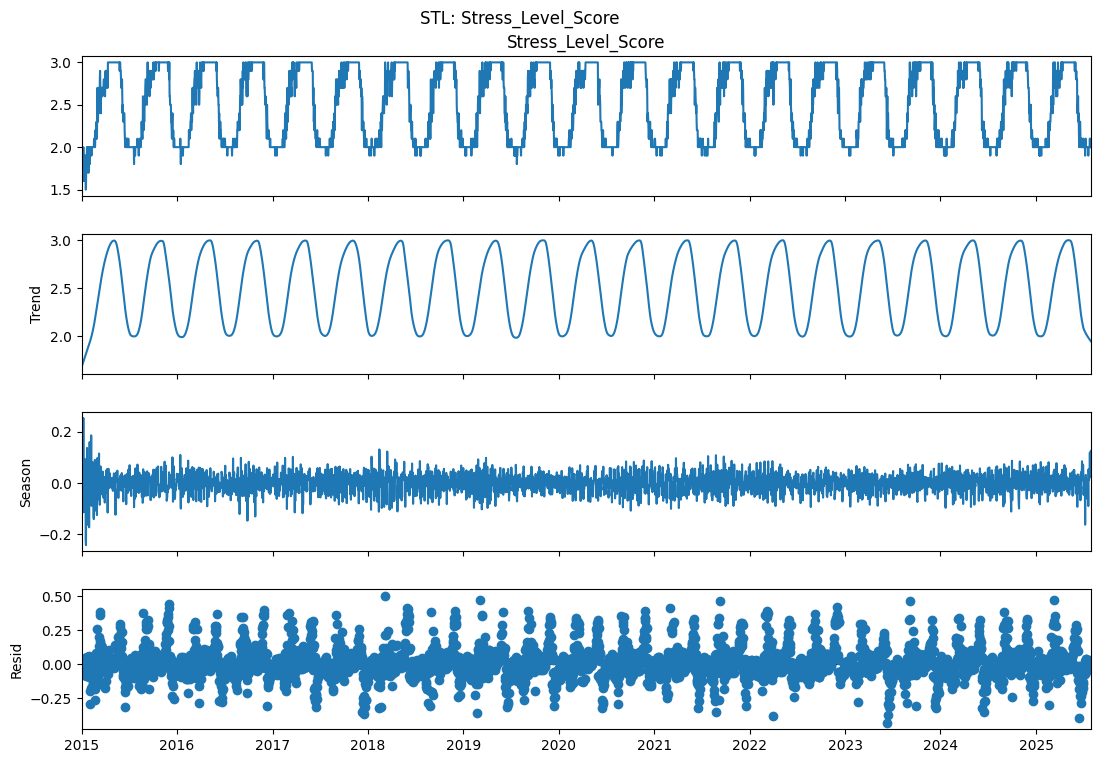


STL Decomposition for Mental_Health_Status_Score


In [ ]:
# %%
# 8) TIME SERIES EDA & DIAGNOSTICS for each target
targets = [c for c in ['Stress_Level_Score','Mental_Health_Status_Score'] if c in df_feat.columns]
print("Targets for analysis:", targets)

# A) STL decomposition
for t in targets:
    print(f"\nSTL Decomposition for {t}")
    try:
        stl = STL(df_feat[t].dropna(), period=30, robust=True)
        res = stl.fit()
        fig = res.plot()
        fig.set_size_inches(12, 8)
        plt.suptitle(f"STL: {t}")
        plt.show()
    except Exception as e:
        print("STL failed:", e)

# B) ACF / PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
for t in targets:
    print(f"\nACF & PACF for {t}")
    series = df_feat[t].dropna()
    plt.figure(figsize=(10,3))
    plot_acf(series, lags=60, ax=plt.gca())
    plt.title(f"ACF - {t}")
    plt.show()
    plt.figure(figsize=(10,3))
    plot_pacf(series, lags=60, method='ywm', ax=plt.gca())
    plt.title(f"PACF - {t}")
    plt.show()

# C) Rolling stats
for t in targets:
    roll_mean = df_feat[t].rolling(30).mean()
    roll_std = df_feat[t].rolling(30).std()
    plt.figure(figsize=(10,3))
    plt.plot(df_feat[t], label='Original')
    plt.plot(roll_mean, label='30-day mean')
    plt.plot(roll_std, label='30-day std')
    plt.legend(); plt.title(f"Rolling stats - {t}")
    plt.show()

# D) ADF test
for t in targets:
    print(f"\nADF test for {t}")
    s = df_feat[t].dropna()
    adf = adfuller(s)
    print("ADF stat:", adf[0], "p-value:", adf[1])
    for k,v in adf[4].items():
        print(k, v)
    print("Stationary?" , "Yes" if adf[1] < 0.05 else "No")

# E) Ljung-Box white noise test
for t in targets:
    print(f"\nLjung-Box for {t}")
    lb = acorr_ljungbox(df_feat[t].dropna(), lags=[20], return_df=True)
    display(lb)
    p = lb['lb_pvalue'].iloc[0]
    print("White-noise?" , "Yes" if p > 0.05 else "No")


In [ ]:
# %%
# 9) Prepare global model sequences (for fallback)
numeric_all = df_feat.select_dtypes(include=[np.number]).columns.tolist()
global_feature_columns = [c for c in numeric_all if c not in targets]
print("Global features count:", len(global_feature_columns))
X_all = df_feat[global_feature_columns].values
y_all = df_feat[targets].values

scaler_X_glob = StandardScaler().fit(X_all)
scaler_y_glob = StandardScaler().fit(y_all)
X_scaled_glob = scaler_X_glob.transform(X_all)
y_scaled_glob = scaler_y_glob.transform(y_all)

def make_sequences(X, y, lookback, horizon):
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback:i+lookback+horizon])
    return np.array(Xs), np.array(ys)

X_seq_glob, y_seq_glob = make_sequences(X_scaled_glob, y_scaled_glob, GLOBAL_LOOKBACK, GLOBAL_HORIZON)
y_flat_glob = y_seq_glob.reshape(y_seq_glob.shape[0], -1)
print("Global sequence shapes:", X_seq_glob.shape, y_flat_glob.shape)


In [ ]:
# %%
# 10) Train small global fallback model
n_g = X_seq_glob.shape[0]
train_g = int(n_g * 0.7)
val_g = int(n_g * 0.85)
Xg_train, Xg_val = X_seq_glob[:train_g], X_seq_glob[train_g:val_g]
yg_train, yg_val = y_flat_glob[:train_g], y_flat_glob[train_g:val_g]

tf.keras.backend.clear_session()
global_model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(GLOBAL_LOOKBACK, Xg_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.1),
    Dense(yg_train.shape[1])
])
global_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
print("Training global fallback model (this may take time)...")
history_global = global_model.fit(
    Xg_train, yg_train,
    validation_data=(Xg_val, yg_val),
    epochs=EPOCHS_GLOBAL,
    batch_size=BATCH_SIZE,
    verbose=2
)

# save
global_model.save(os.path.join(MODEL_DIR, "global_fallback_model.h5"))
joblib.dump(scaler_X_glob, os.path.join(MODEL_DIR, "scaler_X_global.joblib"))
joblib.dump(scaler_y_glob, os.path.join(MODEL_DIR, "scaler_y_global.joblib"))
print("Saved global fallback model and scalers.")


In [ ]:
# %% Global Model: Training vs Validation Loss

plt.figure(figsize=(8,5))
plt.plot(history_global.history['loss'], label='Train Loss')
plt.plot(history_global.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Global Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


In [26]:
n_targets = len(targets)
horizon = GLOBAL_HORIZON

def inverse_scale_seq2seq(y_flat, scaler, horizon, n_targets):
    """
    y_flat: (samples, horizon * n_targets)
    return: (samples, horizon, n_targets)
    """
    y_2d = y_flat.reshape(-1, n_targets)      # (samples*horizon, n_targets)
    y_inv = scaler.inverse_transform(y_2d)    # valid
    return y_inv.reshape(-1, horizon, n_targets)


In [27]:
# %% Global Model Metrics (Train / Val) — FIXED

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    pae = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    return mae, mse, rmse, r2, pae

# Predictions (scaled)
y_train_pred = global_model.predict(Xg_train)
y_val_pred   = global_model.predict(Xg_val)

# ✅ Inverse scaling — CORRECT
y_train_pred_inv = inverse_scale_seq2seq(
    y_train_pred, scaler_y_glob, GLOBAL_HORIZON, n_targets
)
y_val_pred_inv = inverse_scale_seq2seq(
    y_val_pred, scaler_y_glob, GLOBAL_HORIZON, n_targets
)

y_train_true_inv = inverse_scale_seq2seq(
    yg_train, scaler_y_glob, GLOBAL_HORIZON, n_targets
)
y_val_true_inv = inverse_scale_seq2seq(
    yg_val, scaler_y_glob, GLOBAL_HORIZON, n_targets
)

rows = []
for split, yt, yp in [
    ("Train", y_train_true_inv, y_train_pred_inv),
    ("Validation", y_val_true_inv, y_val_pred_inv)
]:
    mae, mse, rmse, r2, pae = regression_metrics(
        yt.flatten(),
        yp.flatten()
    )
    rows.append([split, mae, mse, rmse, r2, pae])

metrics_global = pd.DataFrame(
    rows,
    columns=["Split","MAE","MSE","RMSE","R2","PAE (%)"]
)

display(metrics_global)


82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


,Split,MAE,MSE,RMSE,R2,PAE (%)
0,Train,0.092306,0.016560,0.128684,0.977814,2.730687
1,Validation,0.098231,0.019237,0.138699,0.974351,2.872998


In [28]:
# %%
# 11) Helper: build per-student daily features function (same pattern as global df_feat)
def build_student_daily_features(df_student):
    numeric_cols_local = df_student.select_dtypes(include=[np.number]).columns.tolist()
    for t in ['Stress_Level_Score','Mental_Health_Status_Score']:
        if t in df_student.columns and t not in numeric_cols_local:
            numeric_cols_local.append(t)
    agg = df_student.groupby('date_only')[numeric_cols_local].mean().reset_index().rename(columns={'date_only':'date'})
    agg = agg.set_index('date').asfreq('D')
    agg = agg.interpolate(method='time').ffill().bfill()
    # calendar
    agg['dayofweek'] = agg.index.dayofweek
    agg['month'] = agg.index.month
    agg['is_weekend'] = (agg['dayofweek'] >= 5).astype(int)
    rolling_windows = [7,14,30]
    base_cols = [c for c in ['Stress_Level_Score','Mental_Health_Status_Score','Heart_Rate','Sleep_Duration','Activity_Levels','Cognitive_Load'] if c in agg.columns]
    for base in base_cols:
        for l in [1,7,14]:
            agg[f"{base}_lag_{l}"] = agg[base].shift(l)
        for w in rolling_windows:
            agg[f"{base}_rmean_{w}"] = agg[base].rolling(w, min_periods=1).mean()
            agg[f"{base}_rstd_{w}"] = agg[base].rolling(w, min_periods=1).std().fillna(0)
    agg = agg.interpolate(method='time').ffill().bfill()
    return agg


In [29]:
# %%
# 12) Per-student training loop + forecasting + FULL metrics (FINAL)

student_ids = sorted(df['StudentID'].unique())
per_student_targets = ['Stress_Level_Score','Mental_Health_Status_Score']
n_targets = len(per_student_targets)

def inverse_scale_seq2seq(y_flat, scaler, horizon, n_targets):
    y_2d = y_flat.reshape(-1, n_targets)
    y_inv = scaler.inverse_transform(y_2d)
    return y_inv.reshape(-1, horizon, n_targets)

forecasts_all = []
student_summary = []

for sid in tqdm(student_ids, desc="Per-student loop"):
    df_s = df[df['StudentID'] == sid].copy()
    if df_s.empty:
        continue

    df_s_feat = build_student_daily_features(df_s)

    has_enough = (
        df_s_feat[per_student_targets[0]].notna().sum() >= MIN_HISTORY_DAYS
        and df_s_feat.shape[0] >= (PER_STUDENT_LOOKBACK + PER_STUDENT_HORIZON + 5)
    )

    metrics_row = {
        "StudentID": sid,
        "model_used": None,
        "historical_rows": len(df_s)
    }

    # ===================== PER-STUDENT MODEL =====================
    if has_enough:
        try:
            numeric_cols = df_s_feat.select_dtypes(include=[np.number]).columns.tolist()
            feature_cols = [c for c in numeric_cols if c not in per_student_targets]
            if not feature_cols:
                raise ValueError("No feature columns")

            X = df_s_feat[feature_cols].values
            y = df_s_feat[per_student_targets].values

            scaler_X = StandardScaler().fit(X)
            scaler_y = StandardScaler().fit(y)

            Xs = scaler_X.transform(X)
            ys = scaler_y.transform(y)

            X_seq, y_seq = make_sequences(
                Xs, ys, PER_STUDENT_LOOKBACK, PER_STUDENT_HORIZON
            )

            if X_seq.shape[0] < 10:
                raise ValueError("Too few sequences")

            y_flat = y_seq.reshape(y_seq.shape[0], -1)

            n = X_seq.shape[0]
            tr, va = int(n*0.7), int(n*0.85)
            Xtr, Xva = X_seq[:tr], X_seq[tr:va]
            ytr, yva = y_flat[:tr], y_flat[tr:va]

            tf.keras.backend.clear_session()
            model = Sequential([
                LSTM(64, return_sequences=True, input_shape=(PER_STUDENT_LOOKBACK, Xtr.shape[2])),
                Dropout(0.2),
                LSTM(32),
                Dropout(0.2),
                Dense(128, activation='relu'),
                Dropout(0.1),
                Dense(ytr.shape[1])
            ])
            model.compile(optimizer='adam', loss='mse')

            history = model.fit(
                Xtr, ytr,
                validation_data=(Xva, yva),
                epochs=EPOCHS_STUDENT,
                batch_size=16,
                verbose=0
            )

            # ---------- VALIDATION PREDICTIONS ----------
            yva_pred = model.predict(Xva)

            yva_pred_inv = inverse_scale_seq2seq(
                yva_pred, scaler_y, PER_STUDENT_HORIZON, n_targets
            )
            yva_true_inv = inverse_scale_seq2seq(
                yva, scaler_y, PER_STUDENT_HORIZON, n_targets
            )

            # ---------- GLOBAL METRICS ----------
            mae = mean_absolute_error(yva_true_inv.flatten(), yva_pred_inv.flatten())
            mse = mean_squared_error(yva_true_inv.flatten(), yva_pred_inv.flatten())
            rmse = np.sqrt(mse)
            r2 = r2_score(yva_true_inv.flatten(), yva_pred_inv.flatten())
            pae = np.mean(
                np.abs((yva_true_inv - yva_pred_inv) / (yva_true_inv + 1e-6))
            ) * 100

            # ---------- PER-TARGET METRICS ----------
            for i, t in enumerate(per_student_targets):
                metrics_row[f"Val_MAE_{t}"] = mean_absolute_error(
                    yva_true_inv[:,:,i].flatten(),
                    yva_pred_inv[:,:,i].flatten()
                )
                metrics_row[f"Val_RMSE_{t}"] = np.sqrt(mean_squared_error(
                    yva_true_inv[:,:,i].flatten(),
                    yva_pred_inv[:,:,i].flatten()
                ))
                metrics_row[f"Val_R2_{t}"] = r2_score(
                    yva_true_inv[:,:,i].flatten(),
                    yva_pred_inv[:,:,i].flatten()
                )

            # ---------- HORIZON-WISE ERROR (DAY 1 → DAY H) ----------
            horizon_mae = np.mean(
                np.abs(yva_true_inv - yva_pred_inv), axis=(0,2)
            )

            metrics_row.update({
                "model_used": "per_student",
                "Val_MAE": mae,
                "Val_MSE": mse,
                "Val_RMSE": rmse,
                "Val_R2": r2,
                "Val_PAE": pae,
                "train_loss_curve": history.history['loss'],
                "val_loss_curve": history.history['val_loss'],
                "horizon_MAE": horizon_mae.tolist()
            })

            # ---------- FORECAST ----------
            X_latest = scaler_X.transform(X)
            X_input = X_latest[-PER_STUDENT_LOOKBACK:].reshape(
                1, PER_STUDENT_LOOKBACK, X_latest.shape[1]
            )

            y_pred_flat = model.predict(X_input)
            y_pred_inv = inverse_scale_seq2seq(
                y_pred_flat, scaler_y, PER_STUDENT_HORIZON, n_targets
            )[0]

            future_dates = [
                df_s_feat.index[-1] + timedelta(days=i+1)
                for i in range(PER_STUDENT_HORIZON)
            ]

            forecast_df = pd.DataFrame(
                y_pred_inv,
                index=future_dates,
                columns=per_student_targets
            )
            forecast_df["StudentID"] = sid

            model.save(os.path.join(MODEL_DIR, f"student_{sid}_model.h5"))
            joblib.dump(scaler_X, os.path.join(MODEL_DIR, f"scaler_X_student_{sid}.joblib"))
            joblib.dump(scaler_y, os.path.join(MODEL_DIR, f"scaler_y_student_{sid}.joblib"))

        except Exception as e:
            print(f"Student {sid} → fallback ({e})")
            has_enough = False

    # ===================== GLOBAL FALLBACK =====================
    if not has_enough:
        df_local = df_s_feat.copy()
        for col in global_feature_columns:
            if col not in df_local.columns:
                df_local[col] = 0.0

        X_local = scaler_X_glob.transform(df_local[global_feature_columns].values)
        X_input = X_local[-PER_STUDENT_LOOKBACK:].reshape(
            1, PER_STUDENT_LOOKBACK, X_local.shape[1]
        )

        y_pred_flat = global_model.predict(X_input)
        y_pred_inv = inverse_scale_seq2seq(
            y_pred_flat, scaler_y_glob, PER_STUDENT_HORIZON, n_targets
        )[0]

        future_dates = [
            df_local.index[-1] + timedelta(days=i+1)
            for i in range(PER_STUDENT_HORIZON)
        ]

        forecast_df = pd.DataFrame(
            y_pred_inv,
            index=future_dates,
            columns=per_student_targets
        )
        forecast_df["StudentID"] = sid

        metrics_row.update({
            "model_used": "global_fallback"
        })

    # ---------- SAVE ----------
    forecast_df = forecast_df.reset_index().rename(columns={"index":"date"})
    forecast_df.to_csv(
        os.path.join(MODEL_DIR, f"student_{sid}_forecast_3mo.csv"),
        index=False
    )

    forecasts_all.append(forecast_df)
    student_summary.append(metrics_row)

# ---------- FINAL OUTPUTS ----------
combined_forecasts = pd.concat(forecasts_all, ignore_index=True)
combined_forecasts.to_csv(
    os.path.join(OUTPUT_DIR, "all_students_3mo_forecasts.csv"),
    index=False
)

summary_df = pd.DataFrame(student_summary)
summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "per_student_training_summary.csv"),
    index=False
)

print("✅ Saved forecasts, per-student metrics, loss curves, and horizon errors.")


Per-student loop:   0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


Per-student loop:  10%|█         | 1/10 [01:26<12:54, 86.01s/it]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


Per-student loop:  20%|██        | 2/10 [02:52<11:32, 86.58s/it]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


Per-student loop:  90%|█████████ | 9/10 [12:50<01:25, 85.46s/it]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


Per-student loop: 100%|██████████| 10/10 [14:16<00:00, 85.63s/it]

✅ Saved forecasts, per-student metrics, loss curves, and horizon errors.


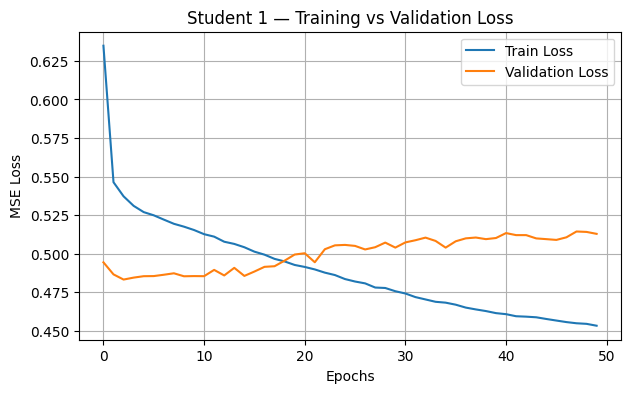

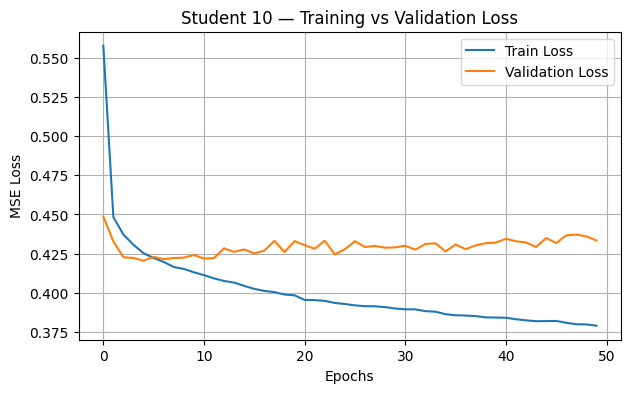

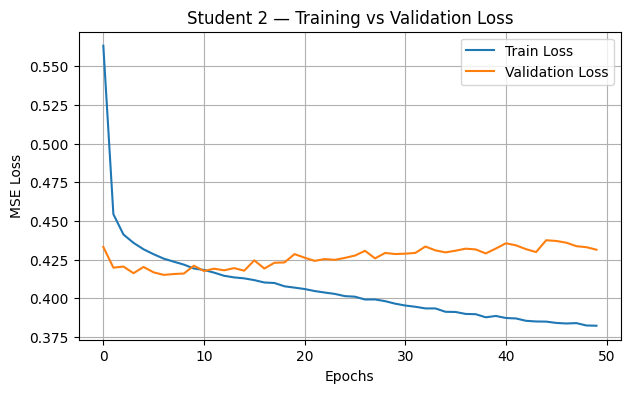

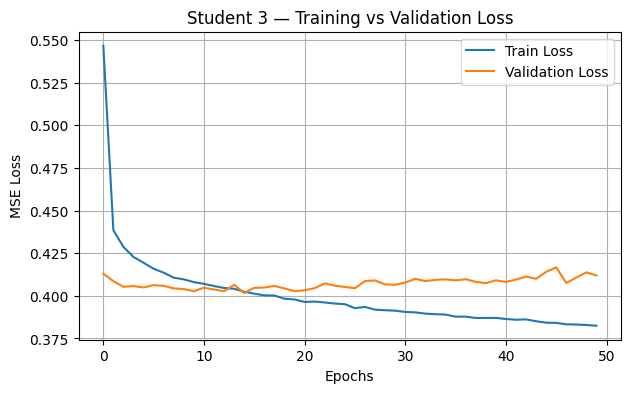

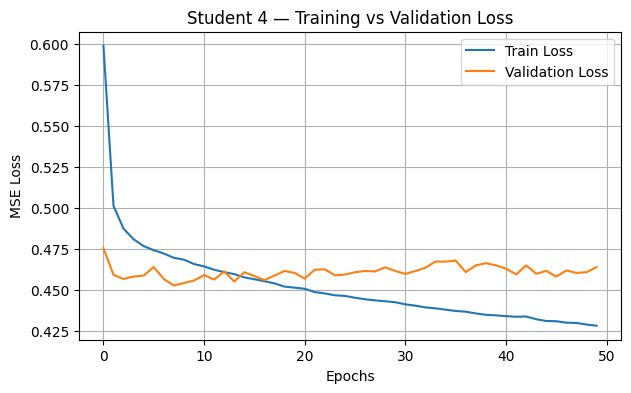

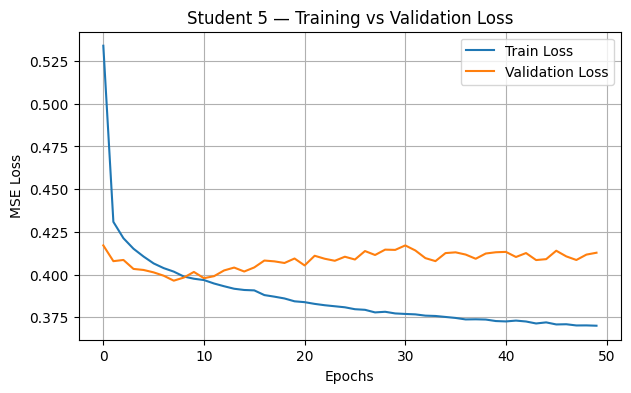

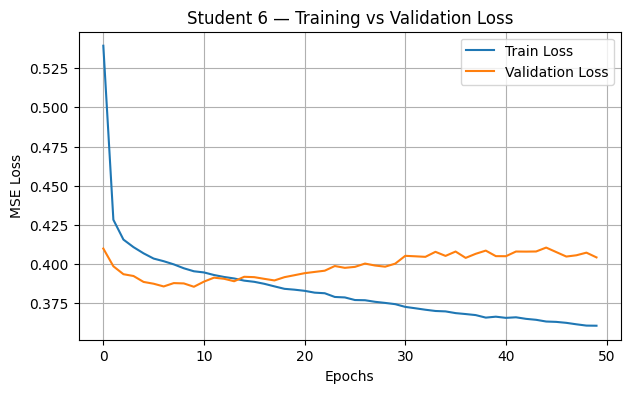

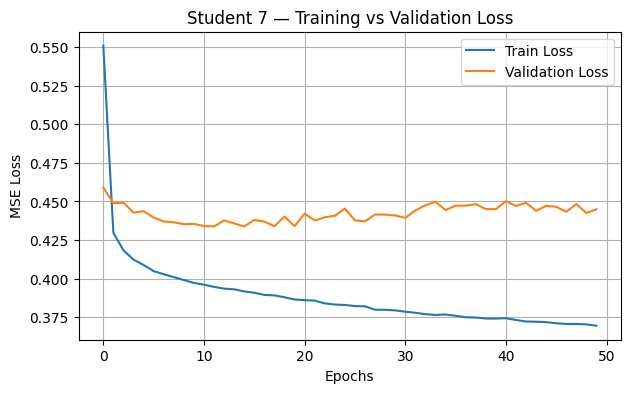

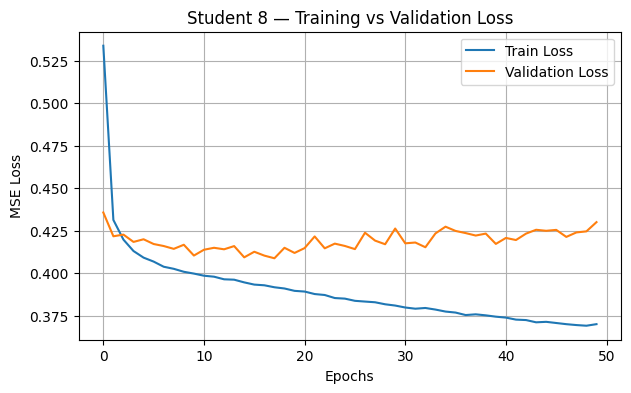

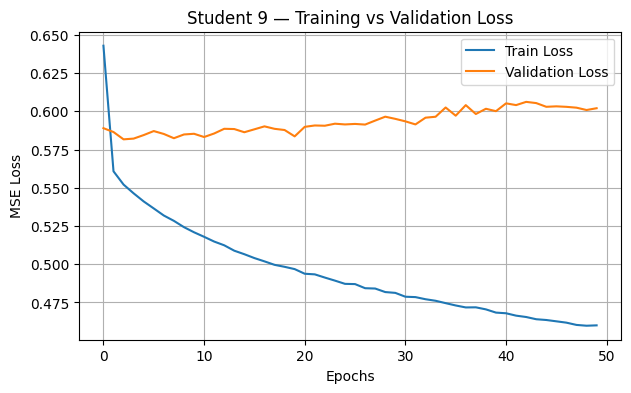

In [30]:
# %%
# Training vs Validation Loss Curves — PER STUDENT

import matplotlib.pyplot as plt

students_with_models = summary_df[
    summary_df['model_used'] == 'per_student'
]

for _, row in students_with_models.iterrows():
    sid = row['StudentID']
    train_loss = row.get('train_loss_curve')
    val_loss = row.get('val_loss_curve')

    if not isinstance(train_loss, list):
        continue

    plt.figure(figsize=(7,4))
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title(f"Student {sid} — Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


In [31]:
def ensure_date_only(df_in):
    df_out = df_in.copy()
    if 'date_only' not in df_out.columns:
        if 'Timestamp' in df_out.columns:
            df_out['date_only'] = pd.to_datetime(df_out['Timestamp']).dt.floor('D')
        elif 'date' in df_out.columns:
            df_out['date_only'] = pd.to_datetime(df_out['date']).dt.floor('D')
        else:
            raise KeyError("No Timestamp/date column found to create date_only")
    return df_out


In [32]:
def get_existing_targets(df_feat, target_list):
    """Return only targets that actually exist in df_feat"""
    return [t for t in target_list if t in df_feat.columns]



===== Student 1 =====
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


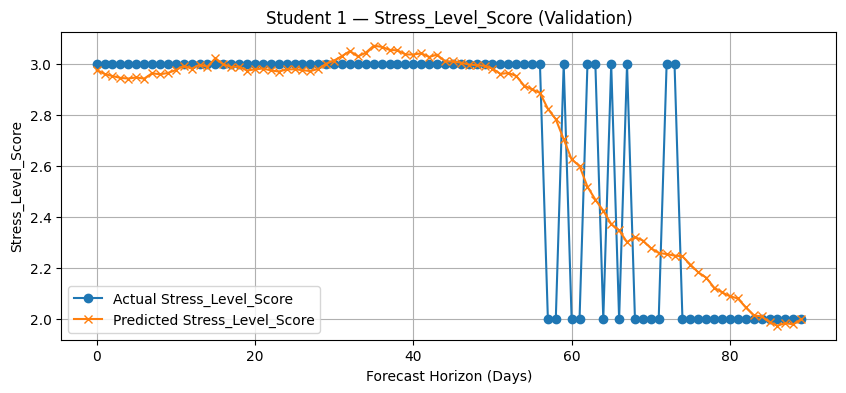

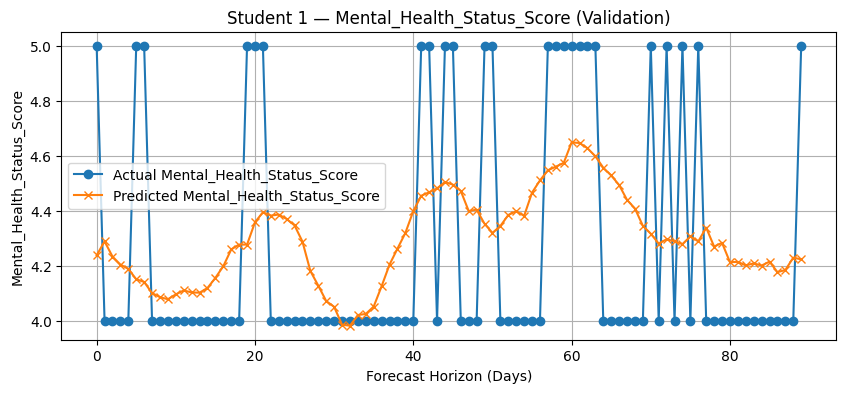


===== Student 10 =====
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


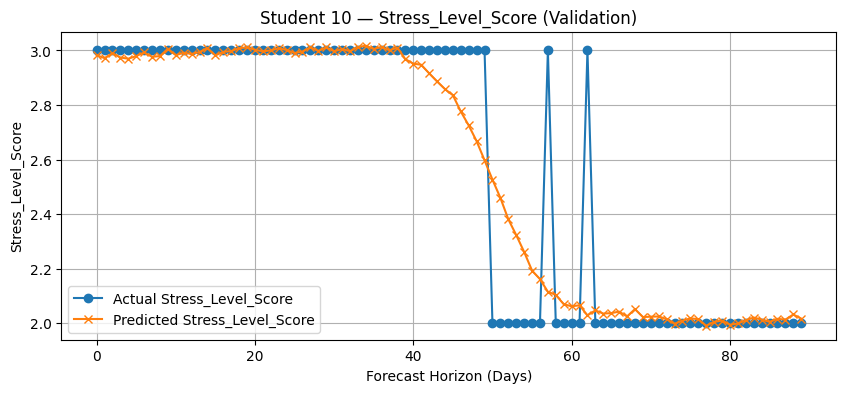

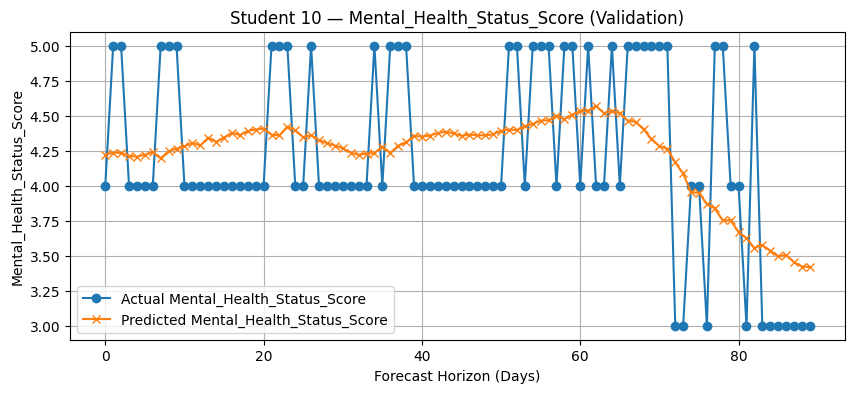


===== Student 2 =====
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


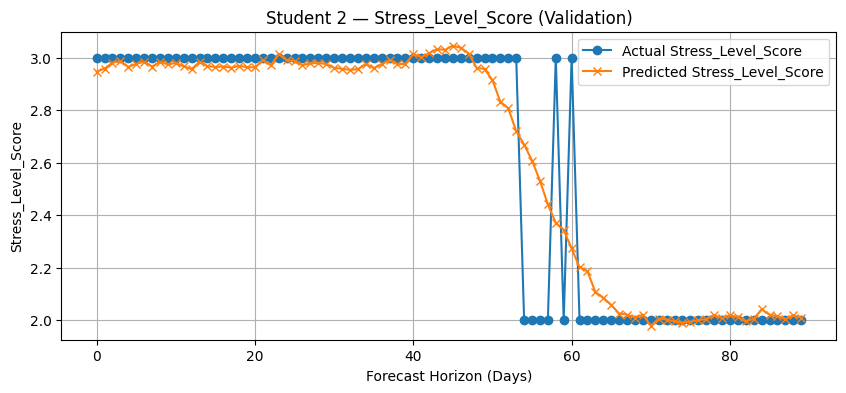

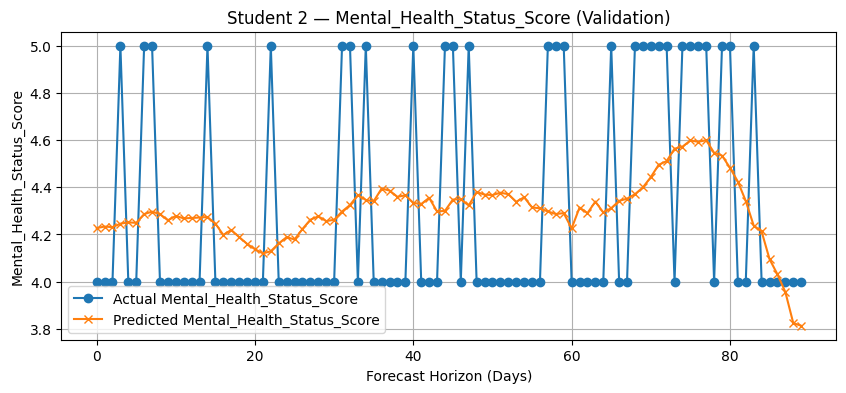


===== Student 3 =====
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


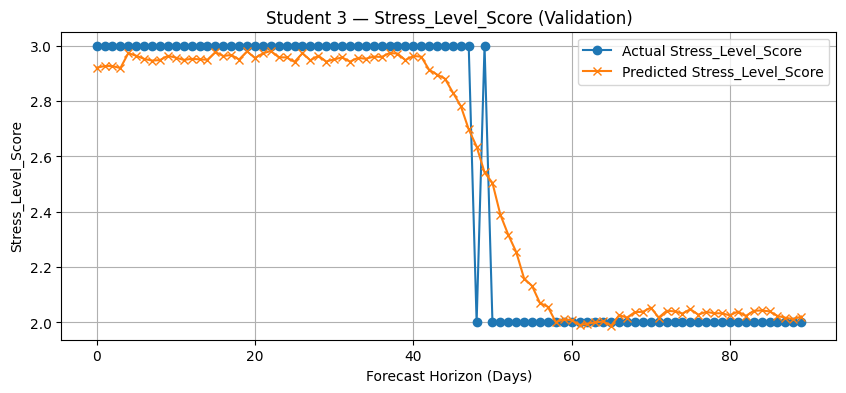

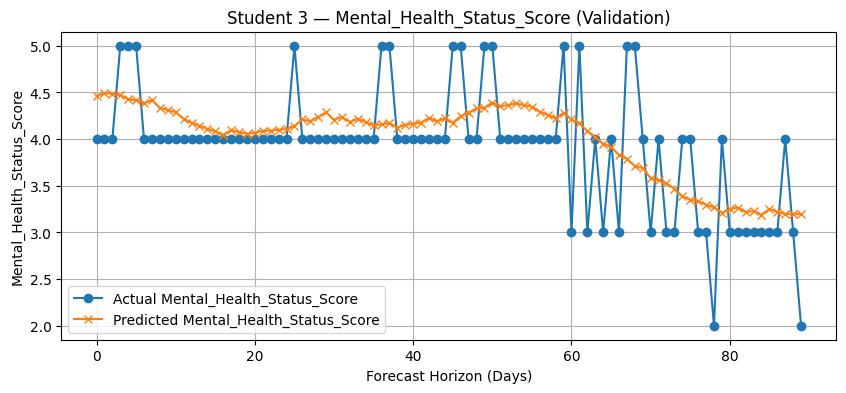


===== Student 4 =====
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


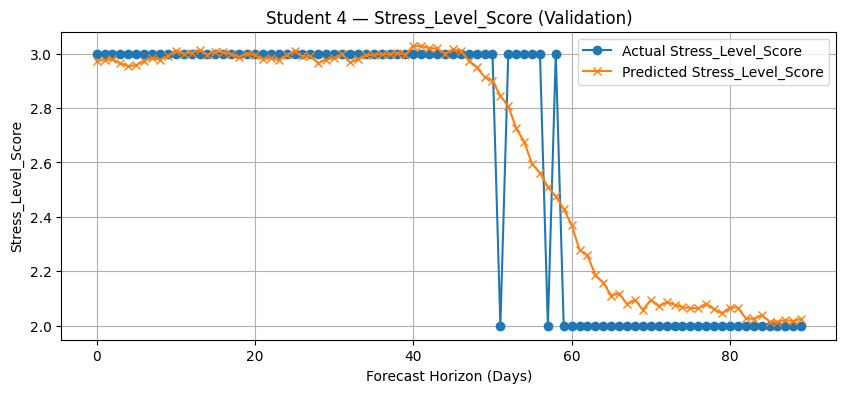

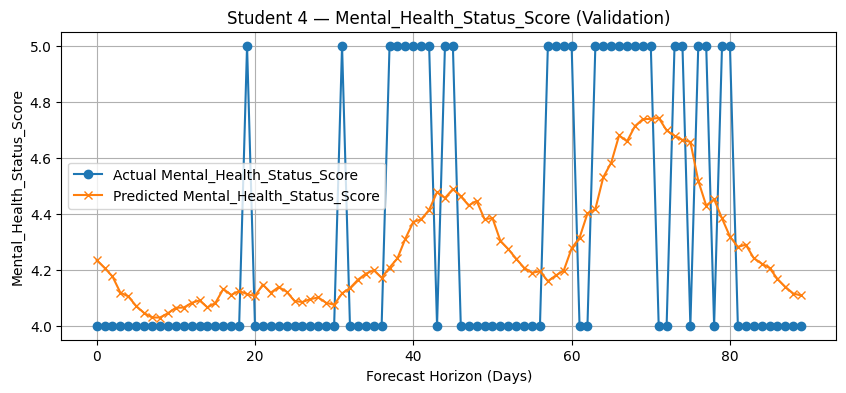


===== Student 5 =====
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


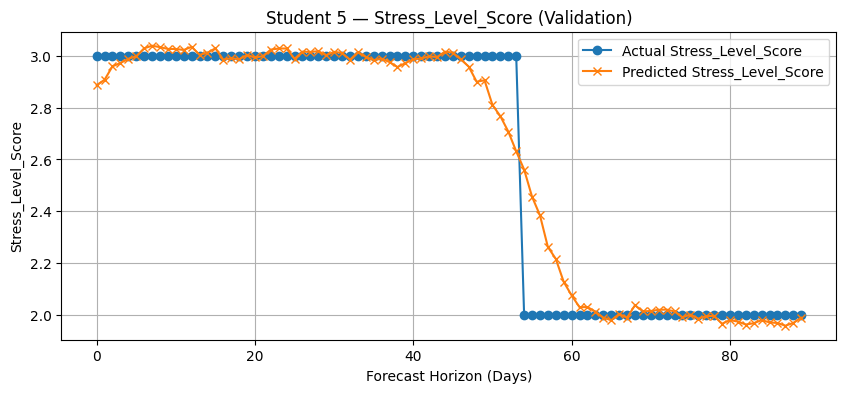

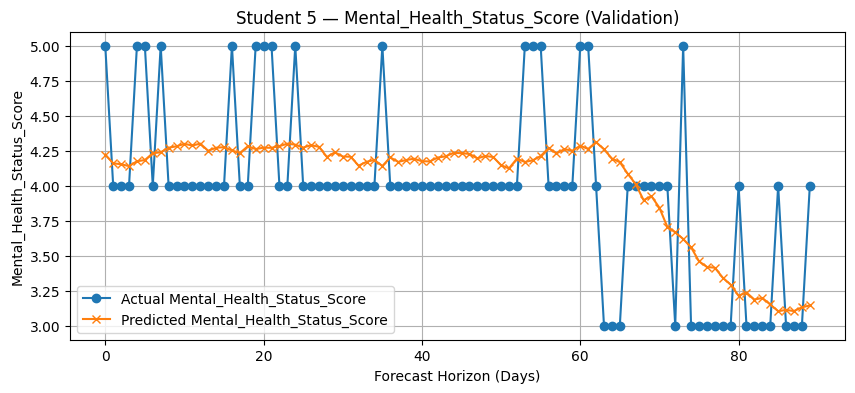


===== Student 6 =====
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


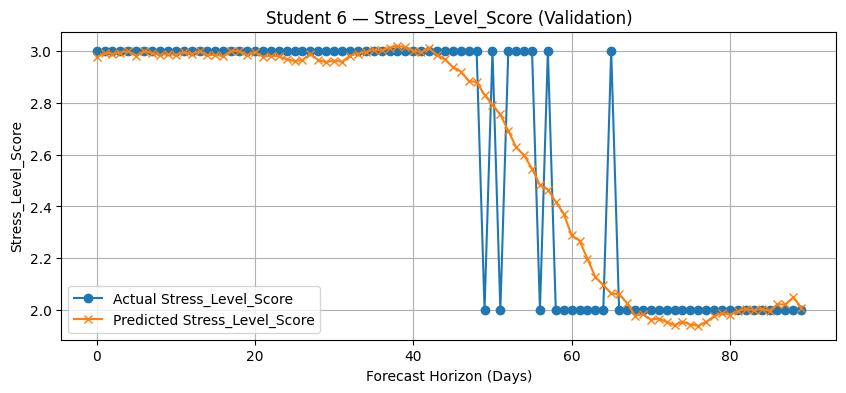

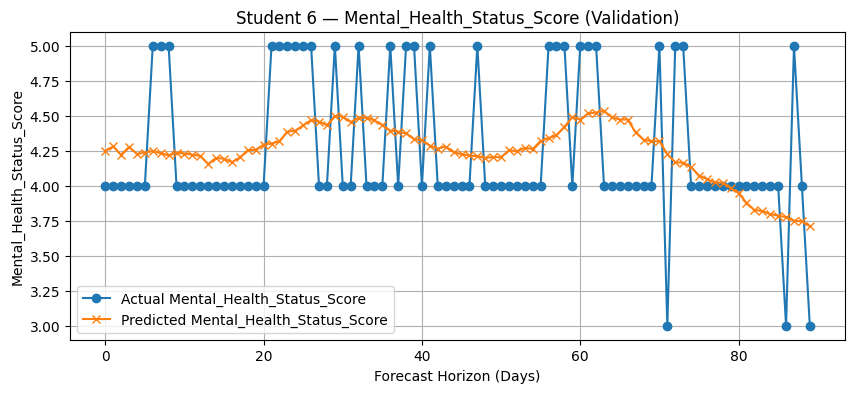


===== Student 7 =====
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


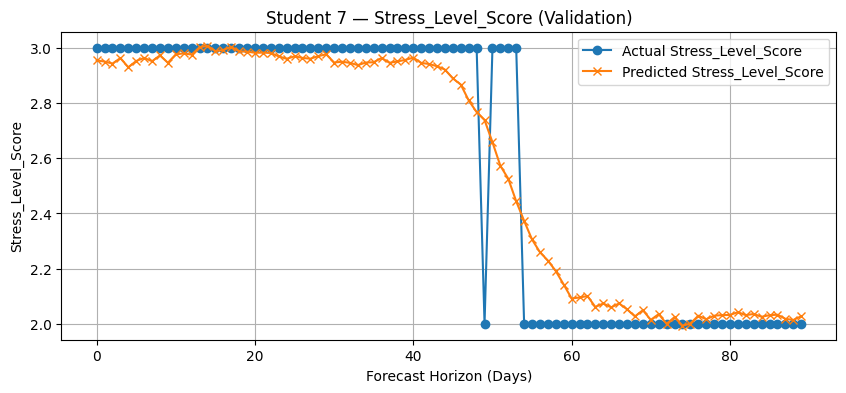

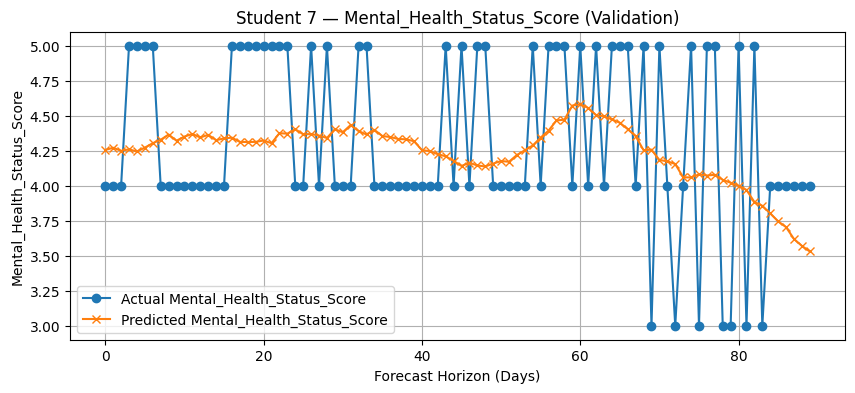


===== Student 8 =====
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


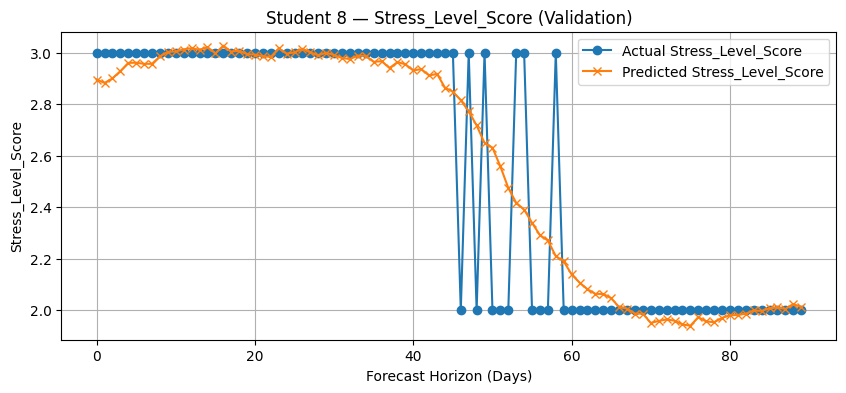

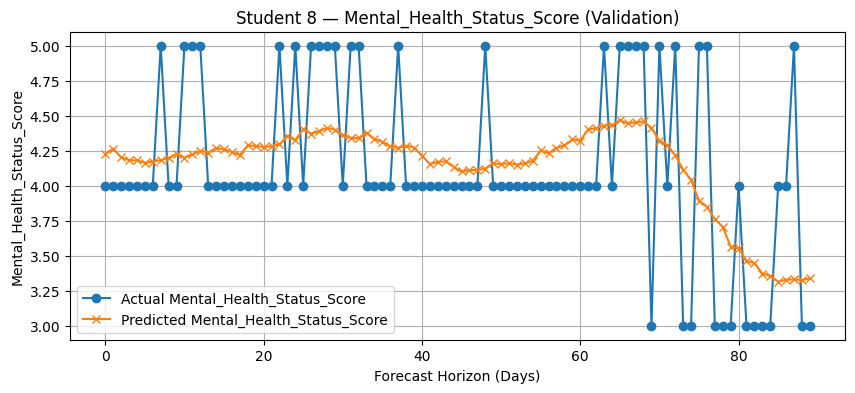


===== Student 9 =====
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


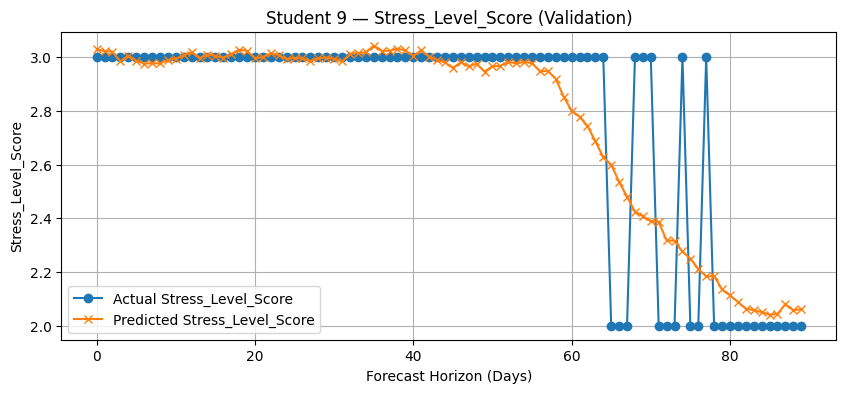

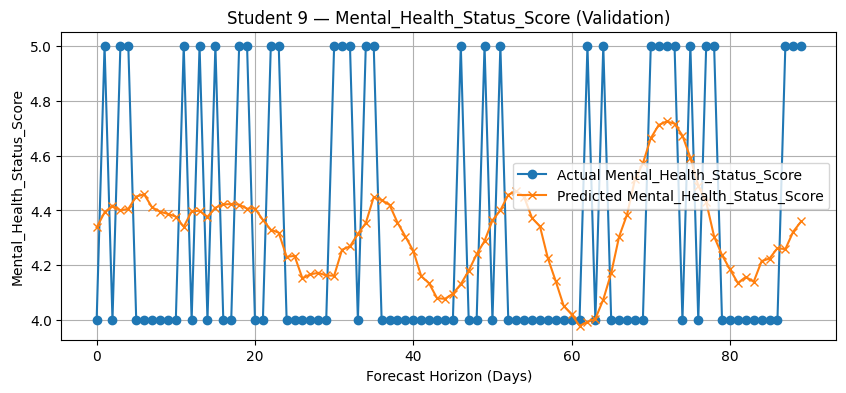

In [33]:
# %%
# Actual vs Predicted Time-Series — PER STUDENT (ROBUST)

for _, row in students_with_models.iterrows():
    sid = row['StudentID']
    print(f"\n===== Student {sid} =====")

    df_s = ensure_date_only(df[df['StudentID'] == sid].copy())
    df_s_feat = build_student_daily_features(df_s)

    # 🔑 Determine which targets exist
    existing_targets = get_existing_targets(df_s_feat, per_student_targets)
    if not existing_targets:
        print("No valid targets available — skipping")
        continue

    numeric_cols = df_s_feat.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in existing_targets]

    if not feature_cols:
        print("No feature columns — skipping")
        continue

    X = df_s_feat[feature_cols].values
    y = df_s_feat[existing_targets].values

    scaler_X = joblib.load(os.path.join(MODEL_DIR, f"scaler_X_student_{sid}.joblib"))
    scaler_y = joblib.load(os.path.join(MODEL_DIR, f"scaler_y_student_{sid}.joblib"))

    Xs = scaler_X.transform(X)
    ys = scaler_y.transform(y)

    X_seq, y_seq = make_sequences(
        Xs, ys,
        PER_STUDENT_LOOKBACK, PER_STUDENT_HORIZON
    )

    if X_seq.shape[0] == 0:
        print("Not enough sequences — skipping")
        continue

    y_flat = y_seq.reshape(y_seq.shape[0], -1)

    n = X_seq.shape[0]
    tr, va = int(n * 0.7), int(n * 0.85)

    Xva = X_seq[tr:va]
    yva = y_flat[tr:va]

    if Xva.shape[0] == 0:
        print("No validation window — skipping")
        continue

    model = tf.keras.models.load_model(
        os.path.join(MODEL_DIR, f"student_{sid}_model.h5"),
        compile=False
    )

    yva_pred = model.predict(Xva)

    yva_pred_inv = inverse_scale_seq2seq(
        yva_pred, scaler_y,
        PER_STUDENT_HORIZON, len(existing_targets)
    )
    yva_true_inv = inverse_scale_seq2seq(
        yva, scaler_y,
        PER_STUDENT_HORIZON, len(existing_targets)
    )

    # Plot first validation sequence for EACH available target
    for i, tgt in enumerate(existing_targets):
        plt.figure(figsize=(10,4))
        plt.plot(yva_true_inv[0,:,i], label=f"Actual {tgt}", marker='o')
        plt.plot(yva_pred_inv[0,:,i], label=f"Predicted {tgt}", marker='x')
        plt.title(f"Student {sid} — {tgt} (Validation)")
        plt.xlabel("Forecast Horizon (Days)")
        plt.ylabel(tgt)
        plt.legend()
        plt.grid(True)
        plt.show()


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


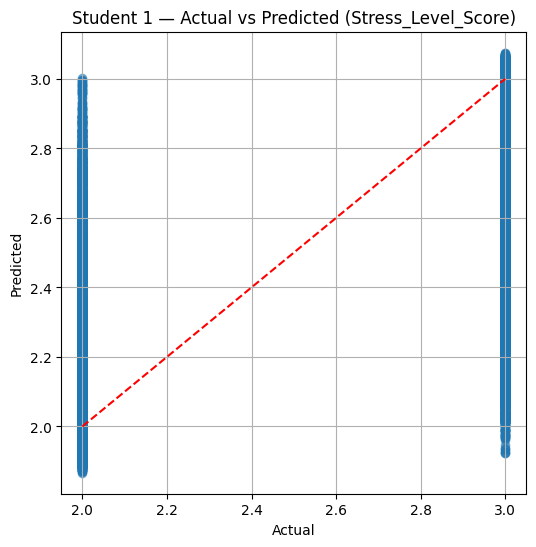

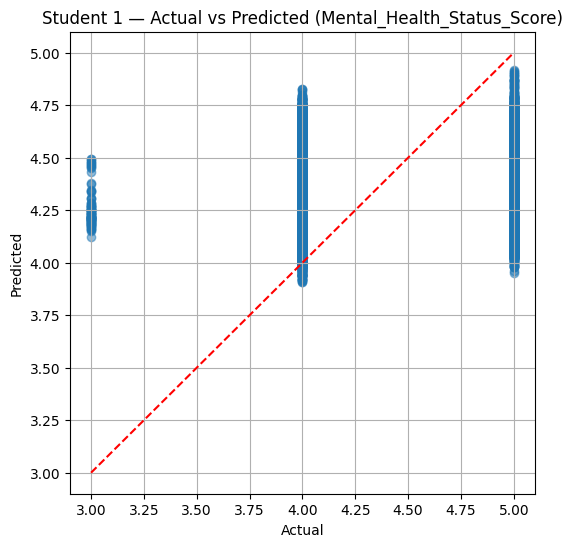

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


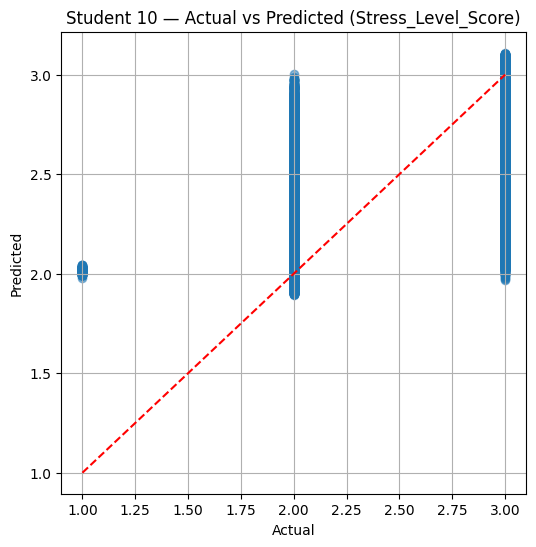

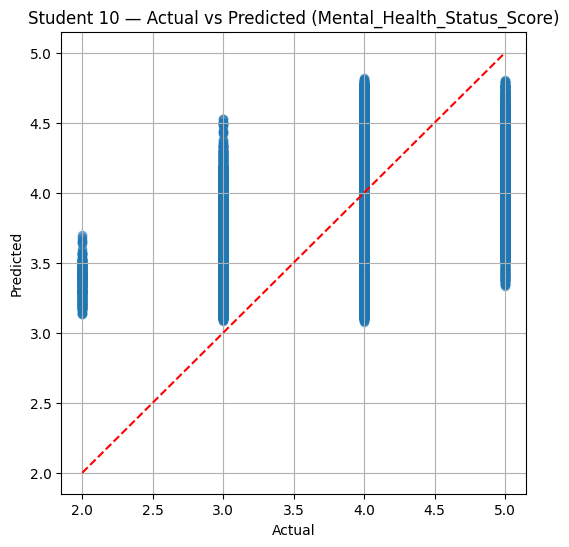

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


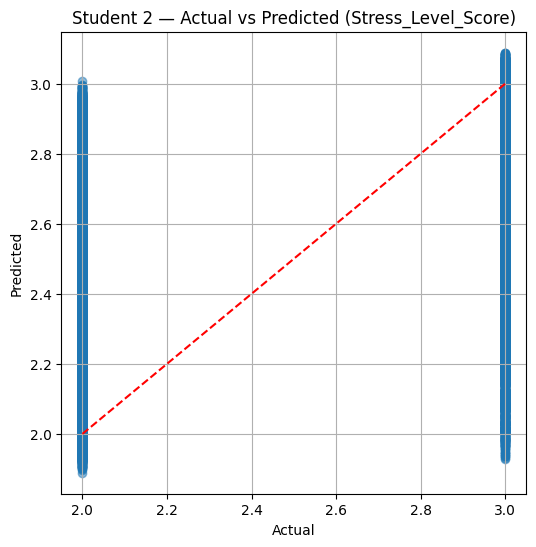

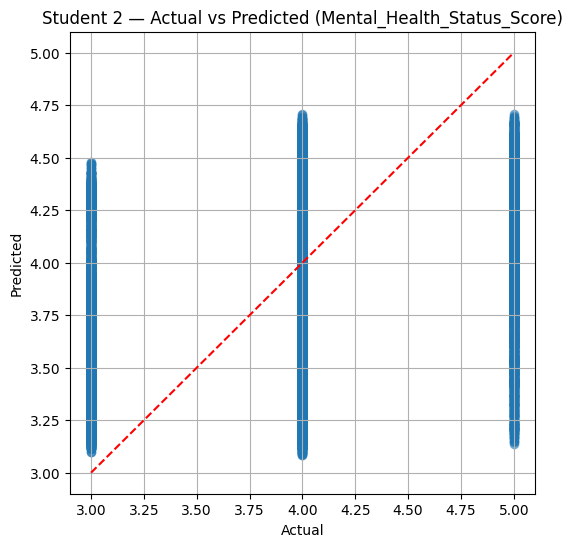

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


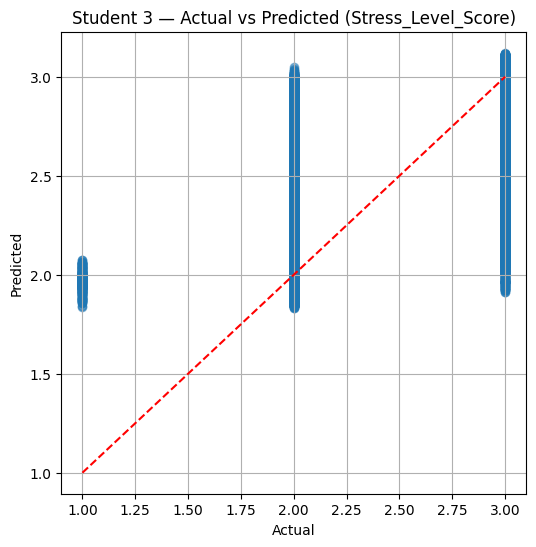

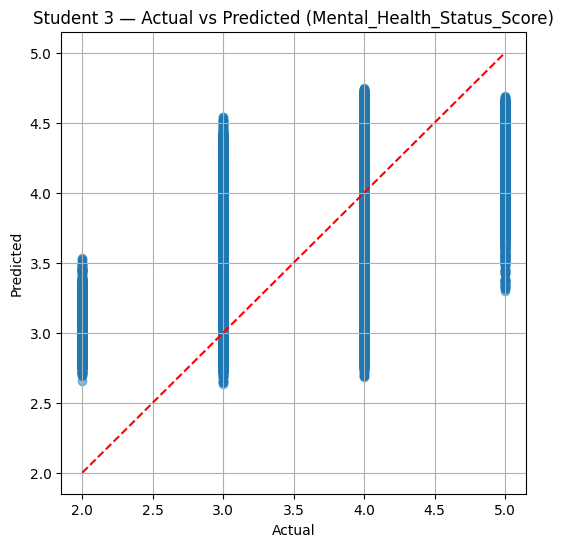

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


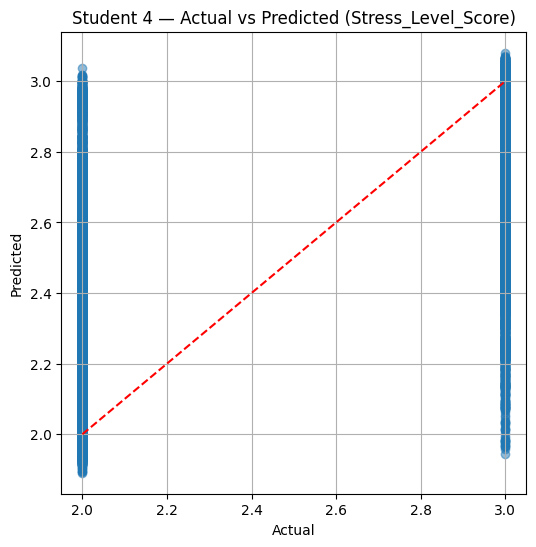

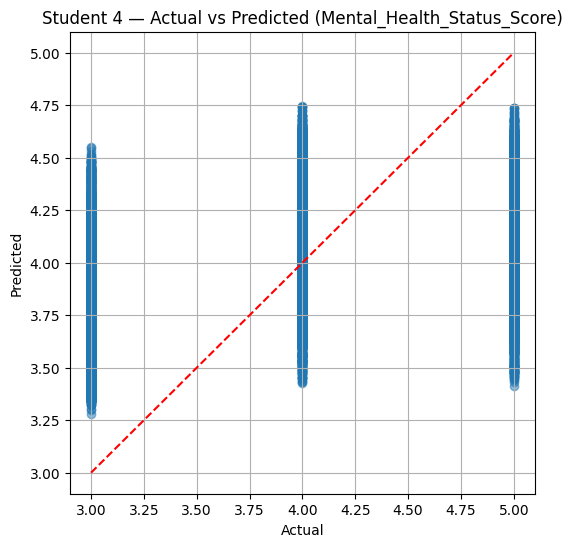

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


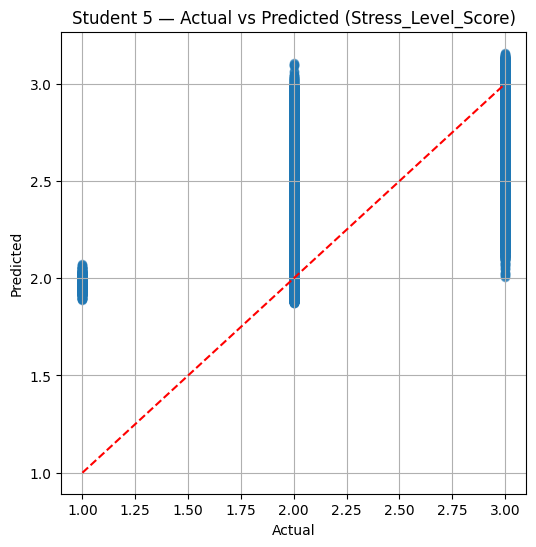

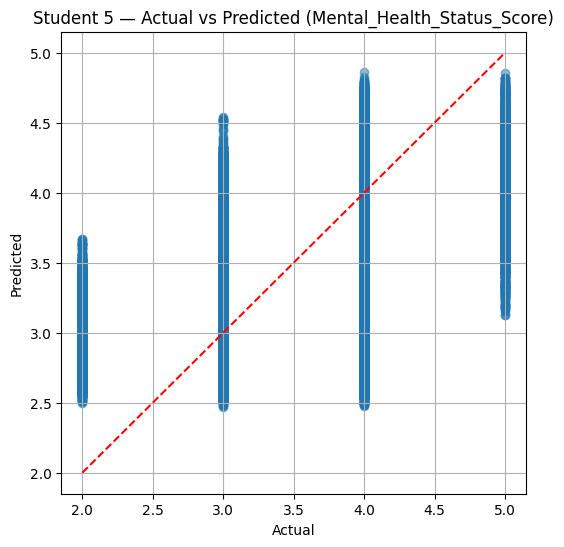

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


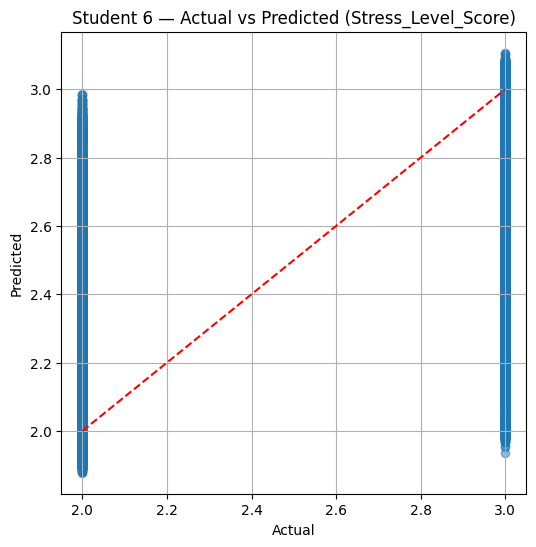

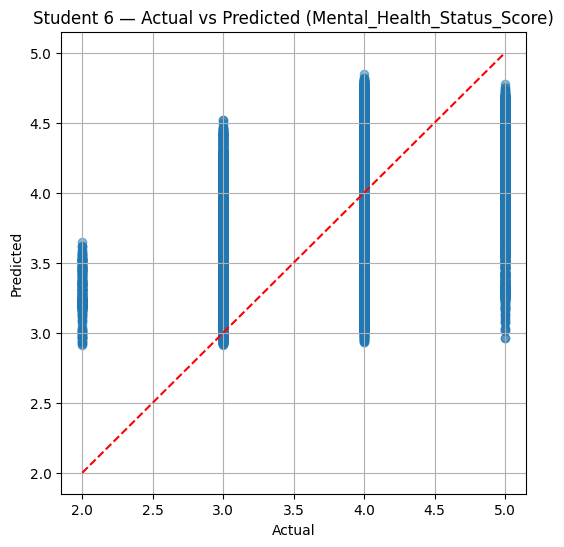

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


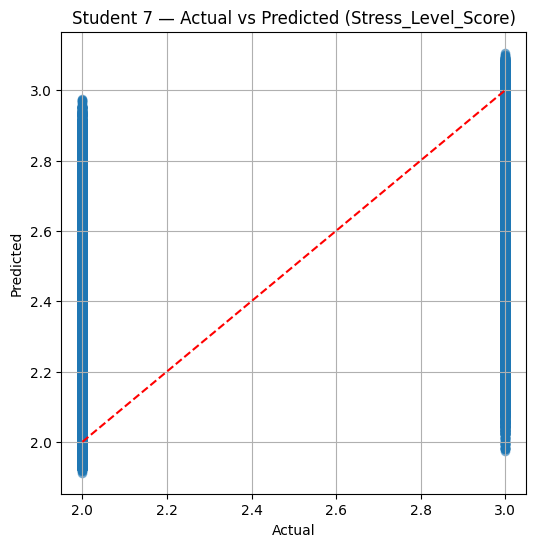

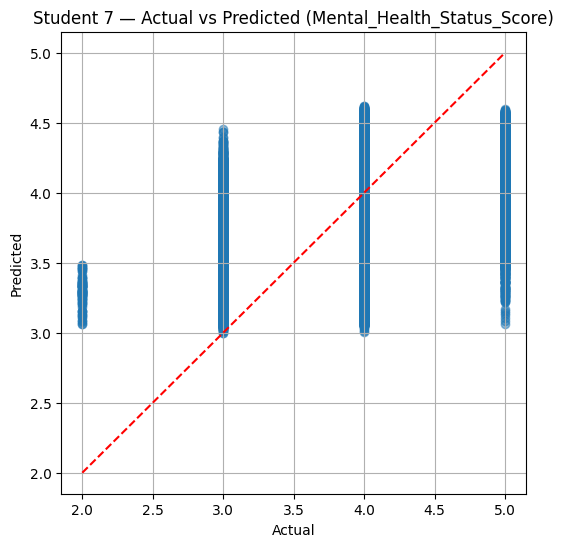

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


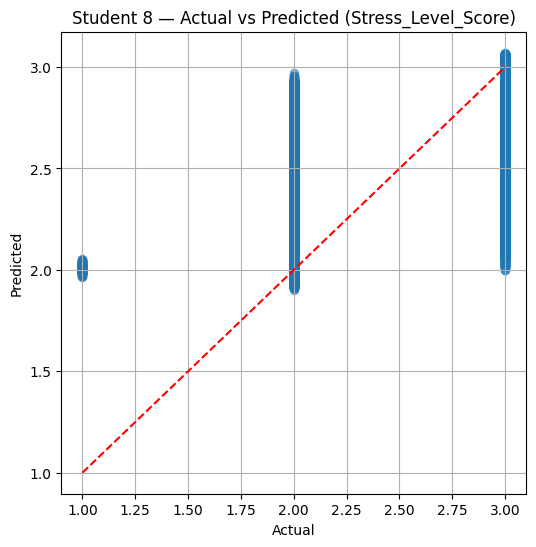

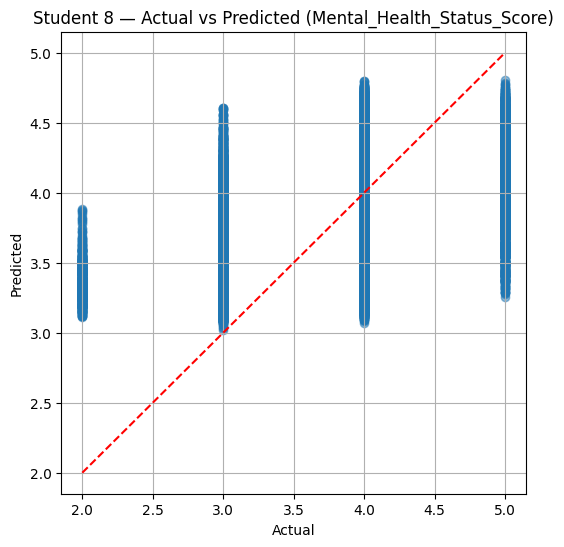

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


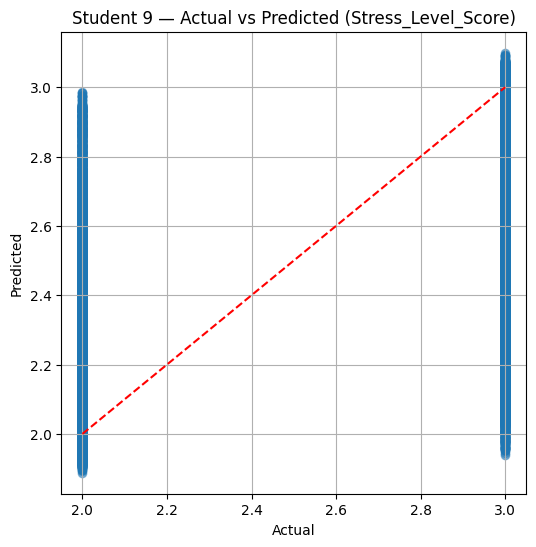

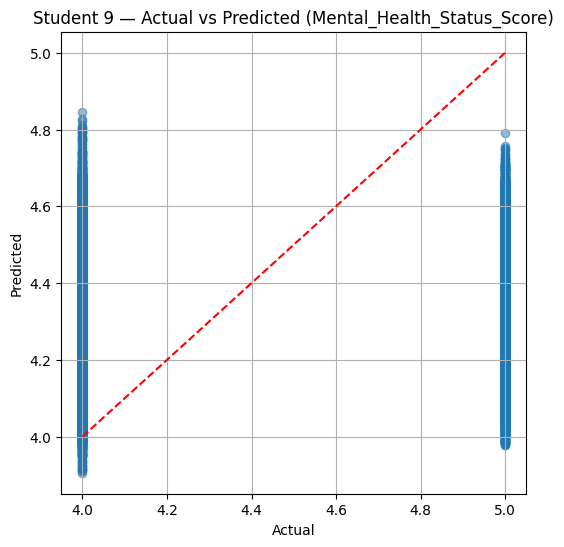

In [34]:
# %%
# Actual vs Predicted Scatter — PER STUDENT (ROBUST)

for _, row in students_with_models.iterrows():
    sid = row['StudentID']

    df_s = ensure_date_only(df[df['StudentID'] == sid].copy())
    df_s_feat = build_student_daily_features(df_s)

    existing_targets = get_existing_targets(df_s_feat, per_student_targets)
    if not existing_targets:
        continue

    numeric_cols = df_s_feat.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in existing_targets]

    if not feature_cols:
        continue

    X = df_s_feat[feature_cols].values
    y = df_s_feat[existing_targets].values

    scaler_X = joblib.load(os.path.join(MODEL_DIR, f"scaler_X_student_{sid}.joblib"))
    scaler_y = joblib.load(os.path.join(MODEL_DIR, f"scaler_y_student_{sid}.joblib"))

    Xs = scaler_X.transform(X)
    ys = scaler_y.transform(y)

    X_seq, y_seq = make_sequences(
        Xs, ys,
        PER_STUDENT_LOOKBACK, PER_STUDENT_HORIZON
    )

    if X_seq.shape[0] == 0:
        continue

    y_flat = y_seq.reshape(y_seq.shape[0], -1)

    n = X_seq.shape[0]
    tr, va = int(n * 0.7), int(n * 0.85)

    Xva = X_seq[tr:va]
    yva = y_flat[tr:va]

    if Xva.shape[0] == 0:
        continue

    model = tf.keras.models.load_model(
        os.path.join(MODEL_DIR, f"student_{sid}_model.h5"),
        compile=False
    )

    yva_pred = model.predict(Xva)

    yva_pred_inv = inverse_scale_seq2seq(
        yva_pred, scaler_y,
        PER_STUDENT_HORIZON, len(existing_targets)
    )
    yva_true_inv = inverse_scale_seq2seq(
        yva, scaler_y,
        PER_STUDENT_HORIZON, len(existing_targets)
    )

    for i, tgt in enumerate(existing_targets):
        plt.figure(figsize=(6,6))
        plt.scatter(
            yva_true_inv[:,:,i].flatten(),
            yva_pred_inv[:,:,i].flatten(),
            alpha=0.5
        )
        plt.plot(
            [yva_true_inv[:,:,i].min(), yva_true_inv[:,:,i].max()],
            [yva_true_inv[:,:,i].min(), yva_true_inv[:,:,i].max()],
            'r--'
        )
        plt.title(f"Student {sid} — Actual vs Predicted ({tgt})")
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.grid(True)
        plt.show()


In [ ]:
# %%
# Actual vs Predicted Scatter — PER STUDENT

for _, row in students_with_models.iterrows():
    sid = row['StudentID']

    df_s = df[df['StudentID'] == sid].copy()
    df_s_feat = build_student_daily_features(df_s)

    numeric_cols = df_s_feat.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in per_student_targets]

    X = df_s_feat[feature_cols].values
    y = df_s_feat[per_student_targets].values

    scaler_X = joblib.load(os.path.join(MODEL_DIR, f"scaler_X_student_{sid}.joblib"))
    scaler_y = joblib.load(os.path.join(MODEL_DIR, f"scaler_y_student_{sid}.joblib"))

    Xs = scaler_X.transform(X)
    ys = scaler_y.transform(y)

    X_seq, y_seq = make_sequences(
        Xs, ys,
        PER_STUDENT_LOOKBACK, PER_STUDENT_HORIZON
    )
    y_flat = y_seq.reshape(y_seq.shape[0], -1)

    n = X_seq.shape[0]
    tr, va = int(n*0.7), int(n*0.85)

    Xva = X_seq[tr:va]
    yva = y_flat[tr:va]

    model = tf.keras.models.load_model(
        os.path.join(MODEL_DIR, f"student_{sid}_model.h5"),
        compile=False
    )

    yva_pred = model.predict(Xva)

    yva_pred_inv = inverse_scale_seq2seq(
        yva_pred, scaler_y,
        PER_STUDENT_HORIZON, len(per_student_targets)
    )
    yva_true_inv = inverse_scale_seq2seq(
        yva, scaler_y,
        PER_STUDENT_HORIZON, len(per_student_targets)
    )

    plt.figure(figsize=(6,6))
    plt.scatter(
        yva_true_inv[:,:,0].flatten(),
        yva_pred_inv[:,:,0].flatten(),
        alpha=0.5
    )
    plt.plot(
        [yva_true_inv[:,:,0].min(), yva_true_inv[:,:,0].max()],
        [yva_true_inv[:,:,0].min(), yva_true_inv[:,:,0].max()],
        'r--'
    )
    plt.title(f"Student {sid} — Actual vs Predicted (Stress)")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.grid(True)
    plt.show()


In [ ]:
# %%
# Per-student Error Metrics (Summary Table)

metric_cols = [
    "StudentID", "model_used",
    "Val_MAE", "Val_MSE", "Val_RMSE", "Val_R2", "Val_PAE",
    "historical_rows"
]

display(summary_df[metric_cols])


In [ ]:
# %%
# Average validation performance across students

summary_df[
    ["Val_MAE", "Val_MSE", "Val_RMSE", "Val_R2", "Val_PAE"]
].mean()


In [ ]:
# %% Actual vs Predicted (Validation) — CORRECT PER-STUDENT

example_sid = summary_df.loc[
    summary_df['model_used'] == 'per_student', 'StudentID'
].iloc[0]

# rebuild student data
df_s = df[df['StudentID'] == example_sid].copy()
df_s_feat = build_student_daily_features(df_s)

numeric_cols_s = df_s_feat.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_s = [c for c in numeric_cols_s if c not in per_student_targets]

Xs = df_s_feat[feature_cols_s].values
ys = df_s_feat[per_student_targets].values

scaler_X_s = joblib.load(os.path.join(MODEL_DIR, f"scaler_X_student_{example_sid}.joblib"))
scaler_y_s = joblib.load(os.path.join(MODEL_DIR, f"scaler_y_student_{example_sid}.joblib"))

Xs_scaled = scaler_X_s.transform(Xs)
ys_scaled = scaler_y_s.transform(ys)

X_seq_s, y_seq_s = make_sequences(
    Xs_scaled, ys_scaled,
    PER_STUDENT_LOOKBACK, PER_STUDENT_HORIZON
)

y_flat_s = y_seq_s.reshape(y_seq_s.shape[0], -1)

ns = X_seq_s.shape[0]
va = int(ns * 0.85)

Xva = X_seq_s[int(ns*0.7):va]
yva = y_flat_s[int(ns*0.7):va]

# load model safely
model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, f"student_{example_sid}_model.h5"),
    compile=False
)

yva_pred = model.predict(Xva)

# inverse scaling (SEQ2SEQ SAFE)
yva_pred_inv = inverse_scale_seq2seq(
    yva_pred, scaler_y_s, PER_STUDENT_HORIZON, len(per_student_targets)
)
yva_true_inv = inverse_scale_seq2seq(
    yva, scaler_y_s, PER_STUDENT_HORIZON, len(per_student_targets)
)

plt.figure(figsize=(6,6))
plt.scatter(yva_true_inv.flatten(), yva_pred_inv.flatten(), alpha=0.5)
plt.plot(
    [yva_true_inv.min(), yva_true_inv.max()],
    [yva_true_inv.min(), yva_true_inv.max()],
    'r--'
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Student {example_sid} – Actual vs Predicted (Validation)")
plt.grid(True)
plt.show()


In [39]:
# # %%
# # 13) Per-student evaluation (optional): compute simple MAE on last available holdout window if possible
# eval_rows = []
# for sid in summary_df['StudentID'].tolist():
#     df_s = df[df['StudentID'] == sid].copy()
#     df_s_feat = build_student_daily_features(df_s)
#     if df_s_feat.shape[0] < (PER_STUDENT_LOOKBACK + 10):
#         continue
#     # Use last (PER_STUDENT_HORIZON) days as pseudo-test if ground truth exists
#     last_dates = df_s_feat.index[-PER_STUDENT_HORIZON:]
#     # if ground-truth exists for these days
#     if df_s_feat.loc[last_dates, per_student_targets].notna().all(axis=None):
#         # Use model (per-student if exists else global) to forecast and compare
#         # Load model/scalers accordingly
#         model_used = summary_df.loc[summary_df['StudentID']==sid, 'model_used'].values[0]
#         try:
#             if model_used == 'per_student':
#                 model_path = os.path.join(MODEL_DIR, f"student_{sid}_model.h5")
#                 scaler_X_s = joblib.load(os.path.join(MODEL_DIR, f"scaler_X_student_{sid}.joblib"))
#                 scaler_y_s = joblib.load(os.path.join(MODEL_DIR, f"scaler_y_student_{sid}.joblib"))
#                 model_s = tf.keras.models.load_model(model_path)
#                 feature_cols_s = [c for c in df_s_feat.select_dtypes(include=[np.number]).columns.tolist() if c not in per_student_targets]
#                 X_latest = df_s_feat[feature_cols_s].values
#                 X_latest_scaled = scaler_X_s.transform(X_latest)
#                 X_input = X_latest_scaled[-PER_STUDENT_LOOKBACK:].reshape(1, PER_STUDENT_LOOKBACK, X_latest_scaled.shape[1])
#                 y_pred_flat = model_s.predict(X_input)
#                 y_pred = y_pred_flat.reshape(PER_STUDENT_HORIZON, len(per_student_targets))
#                 y_pred_inv = scaler_y_s.inverse_transform(y_pred)
#             else:
#                 X_local = df_s_feat[global_feature_columns].values
#                 X_local_scaled = scaler_X_glob.transform(X_local)
#                 X_input = X_local_scaled[-PER_STUDENT_LOOKBACK:].reshape(1, PER_STUDENT_LOOKBACK, X_local_scaled.shape[1])
#                 y_pred_flat = global_model.predict(X_input)
#                 y_pred = y_pred_flat.reshape(PER_STUDENT_HORIZON, len(per_student_targets))
#                 y_pred_inv = scaler_y_glob.inverse_transform(y_pred)
#             # compute MAE over horizon comparing to actual last_dates
#             actual = df_s_feat.loc[last_dates, per_student_targets].values
#             mae = mean_absolute_error(actual, y_pred_inv)
#             eval_rows.append({'StudentID': sid, 'model_used': model_used, 'MAE_horizon': mae})
#         except Exception as e:
#             print("Evaluation skipped for", sid, ":", e)

# eval_df = pd.DataFrame(eval_rows)
# eval_df.to_csv(os.path.join(OUTPUT_DIR, "per_student_eval_summary.csv"), index=False)
# display(eval_df.head())


In [ ]:
# %%
# 14) Visualization examples:
# A) Plot summary of which students used per-student models vs fallback
display(summary_df.head(20))

plt.figure(figsize=(8,4))
model_counts = summary_df['model_used'].value_counts()
model_counts.plot(kind='bar')
plt.title("Per-student model types")
plt.ylabel("Count")
plt.show()

# B) Plot 3-month forecast for a chosen student (replace sid_choice)
sid_choice = student_ids[0] if len(student_ids)>0 else None
if sid_choice is not None:
    sf = combined_forecasts[combined_forecasts['StudentID'] == sid_choice].set_index('date')
    if not sf.empty:
        plt.figure(figsize=(12,4))
        for t in per_student_targets:
            plt.plot(pd.to_datetime(sf.index), sf[t], label=f"Pred {t}")
        plt.title(f"3-month daily forecast for Student {sid_choice}")
        plt.legend(); plt.grid(True); plt.show()
    else:
        print("No forecast available for student", sid_choice)


In [41]:
# %%
# 15) Inference helper: forecast for one student on demand (loads student model if exists else fallback)
def forecast_for_student(student_id, horizon=PER_STUDENT_HORIZON):
    df_s = df[df['StudentID'] == student_id].copy()
    if df_s.empty:
        raise ValueError("No data for student " + str(student_id))
    df_s_feat = build_student_daily_features(df_s)
    # decide if per-student model exists
    model_path = os.path.join(MODEL_DIR, f"student_{student_id}_model.h5")
    if os.path.exists(model_path):
        scaler_X_s = joblib.load(os.path.join(MODEL_DIR, f"scaler_X_student_{student_id}.joblib"))
        scaler_y_s = joblib.load(os.path.join(MODEL_DIR, f"scaler_y_student_{student_id}.joblib"))
        model_s = tf.keras.models.load_model(model_path)
        feature_cols_s = [c for c in df_s_feat.select_dtypes(include=[np.number]).columns.tolist() if c not in per_student_targets]
        X_latest = df_s_feat[feature_cols_s].values
        X_latest_scaled = scaler_X_s.transform(X_latest)
        if X_latest_scaled.shape[0] < PER_STUDENT_LOOKBACK:
            pad_n = PER_STUDENT_LOOKBACK - X_latest_scaled.shape[0]
            pad = np.repeat(X_latest_scaled[:1], pad_n, axis=0)
            X_latest_scaled = np.vstack([pad, X_latest_scaled])
        X_input = X_latest_scaled[-PER_STUDENT_LOOKBACK:].reshape(1, PER_STUDENT_LOOKBACK, X_latest_scaled.shape[1])
        y_pred_flat = model_s.predict(X_input)
        y_pred = y_pred_flat.reshape(horizon, len(per_student_targets))
        y_pred_inv = scaler_y_s.inverse_transform(y_pred)
    else:
        # fallback global
        df_local = df_s_feat.copy()
        for col in global_feature_columns:
            if col not in df_local.columns:
                df_local[col] = 0.0
        X_local = df_local[global_feature_columns].values
        X_local_scaled = scaler_X_glob.transform(X_local)
        if X_local_scaled.shape[0] < PER_STUDENT_LOOKBACK:
            pad_n = PER_STUDENT_LOOKBACK - X_local_scaled.shape[0]
            pad = np.repeat(X_local_scaled[:1], pad_n, axis=0)
            X_local_scaled = np.vstack([pad, X_local_scaled])
        X_input = X_local_scaled[-PER_STUDENT_LOOKBACK:].reshape(1, PER_STUDENT_LOOKBACK, X_local_scaled.shape[1])
        y_pred_flat = global_model.predict(X_input)
        y_pred = y_pred_flat.reshape(horizon, len(per_student_targets))
        y_pred_inv = scaler_y_glob.inverse_transform(y_pred)
    last_date = df_s_feat.index[-1]
    future_dates = [last_date + timedelta(days=i+1) for i in range(horizon)]
    return pd.DataFrame(y_pred_inv, index=future_dates, columns=per_student_targets)

# Example usage:
# example_forecast = forecast_for_student(student_ids[0])
# display(example_forecast.head())


In [42]:
# # %%
# # 16) Final notes & saved outputs
# print("Outputs saved under:", OUTPUT_DIR)
# print("- Combined per-student forecasts:", combined_out)
# print("- Per-student model files/CSVs in:", MODEL_DIR)
# print("- Per-student summary:", os.path.join(OUTPUT_DIR, "per_student_training_summary.csv"))
# print("- Per-student evaluation (if computed):", os.path.join(OUTPUT_DIR, "per_student_eval_summary.csv"))


In [43]:
# %%
# A) Setup: inverse mappings and utility functions
import os
import numpy as np
import pandas as pd

# inverse label maps (numeric -> text)
inv_stress_map = {
    1: "Low",
    2: "Medium",
    3: "High"
}

# We'll prefer these canonical names for mental health integer scores
inv_mental_map = {
    1: "Normal",
    2: "Mild Stress",
    3: "Moderate Stress",
    4: "Depression",
    5: "Severe Stress"
}

# Clip function to ensure integer falls in allowed range
def numeric_to_label_stress(x):
    if np.isnan(x):
        return "Unknown"
    val = int(np.round(x))
    val = max(1, min(3, val))
    return inv_stress_map[val]

def numeric_to_label_mental(x):
    if np.isnan(x):
        return "Unknown"
    val = int(np.round(x))
    val = max(1, min(5, val))
    return inv_mental_map[val]


In [44]:
# %%
# B) Load existing numeric forecasts if available; otherwise compute forecasts per-student using forecast_for_student()
# This cell prefers a saved combined file because recomputing can be slow.
COMBINED_PATH = os.path.join(OUTPUT_DIR, "all_students_3mo_forecasts.csv")

if os.path.exists(COMBINED_PATH):
    print("Loading saved combined forecasts:", COMBINED_PATH)
    combined_forecasts = pd.read_csv(COMBINED_PATH, parse_dates=['date'])
else:
    print("Saved combined forecasts not found — computing forecasts for every student using forecast_for_student().")
    # Ensure forecast_for_student function and df, student_ids exist from previous cells
    combined_list = []
    for sid in student_ids:
        try:
            df_pred = forecast_for_student(sid, horizon=PER_STUDENT_HORIZON)  # returns DataFrame indexed by date
            df_pred = df_pred.reset_index().rename(columns={'index':'date'})
            df_pred['StudentID'] = sid
            combined_list.append(df_pred)
        except Exception as e:
            print(f"Warning: could not forecast for Student {sid} -> {e}")
    if not combined_list:
        raise RuntimeError("No forecasts produced. Ensure forecast_for_student is available and students exist.")
    combined_forecasts = pd.concat(combined_list, ignore_index=True)
    combined_forecasts.to_csv(COMBINED_PATH, index=False)
    print("Saved combined forecasts to:", COMBINED_PATH)

# show structure
print("combined_forecasts columns:", combined_forecasts.columns.tolist())
display(combined_forecasts.head(6))


Loading saved combined forecasts: newdata/forecast_outputs/all_students_3mo_forecasts.csv
combined_forecasts columns: ['date', 'Stress_Level_Score', 'Mental_Health_Status_Score', 'StudentID']


,date,Stress_Level_Score,Mental_Health_Status_Score,StudentID
0,2025-08-01,2.006550,4.145948,1
1,2025-08-02,2.002248,4.135597,1
2,2025-08-03,1.997788,4.073204,1
3,2025-08-04,2.005544,4.073169,1
4,2025-08-05,2.007826,4.068109,1
5,2025-08-06,2.010809,4.069940,1


In [45]:
# %%
# C) Convert numeric predictions to text labels and save per-student CSVs
OUT_LABELED_DIR = os.path.join(OUTPUT_DIR, "per_student_labeled_3mo")
os.makedirs(OUT_LABELED_DIR, exist_ok=True)

# Ensure expected numeric columns exist; adapt names if necessary
num_stress_col = 'Stress_Level_Score' if 'Stress_Level_Score' in combined_forecasts.columns else 'Stress_Level'
num_mental_col = 'Mental_Health_Status_Score' if 'Mental_Health_Status_Score' in combined_forecasts.columns else 'Mental_Health_Status'

labeled_rows = []
student_list = combined_forecasts['StudentID'].unique().tolist()
for sid in student_list:
    df_s = combined_forecasts[combined_forecasts['StudentID'] == sid].copy()
    if df_s.empty:
        continue
    # Convert numeric columns (they might be floats already)
    df_s['stress_pred_numeric'] = pd.to_numeric(df_s[num_stress_col], errors='coerce')
    df_s['mental_pred_numeric'] = pd.to_numeric(df_s[num_mental_col], errors='coerce')
    # Map to labels
    df_s['stress_pred_label'] = df_s['stress_pred_numeric'].apply(numeric_to_label_stress)
    df_s['mental_pred_label'] = df_s['mental_pred_numeric'].apply(numeric_to_label_mental)
    # Reorder columns to be human-friendly
    cols_order = ['StudentID', 'date', 'stress_pred_numeric', 'stress_pred_label', 'mental_pred_numeric', 'mental_pred_label']
    # some combined files may have extra columns; keep only those present
    cols_order = [c for c in cols_order if c in df_s.columns]
    df_s_out = df_s[cols_order].copy()
    # Save per-student CSV
    out_path = os.path.join(OUT_LABELED_DIR, f"student_{sid}_labeled_3mo.csv")
    df_s_out.to_csv(out_path, index=False)
    labeled_rows.append(df_s_out)
print("Saved labeled CSVs to:", OUT_LABELED_DIR)
print("Example files:", os.listdir(OUT_LABELED_DIR)[:6])


Saved labeled CSVs to: newdata/forecast_outputs/per_student_labeled_3mo
Example files: ['student_5_labeled_3mo.csv', 'student_3_labeled_3mo.csv', 'student_4_labeled_3mo.csv', 'student_7_labeled_3mo.csv', 'student_6_labeled_3mo.csv', 'student_1_labeled_3mo.csv']


In [46]:
# %%
# D) Show the full daily labeled forecast for a chosen student (text labels)
# Replace sid_choice with a StudentID to inspect, or keep default to first student found.
sid_choice = student_list[0] if len(student_list)>0 else None
if sid_choice is None:
    print("No students found in combined forecasts.")
else:
    sample_file = os.path.join(OUT_LABELED_DIR, f"student_{sid_choice}_labeled_3mo.csv")
    if os.path.exists(sample_file):
        df_show = pd.read_csv(sample_file, parse_dates=['date'])
        # Print a concise table showing date and both text labels
        display(df_show[['date','stress_pred_label','mental_pred_label']].head(180))  # show up to 180 rows (3 months)
    else:
        print("Sample file not found for student", sid_choice)


,date,stress_pred_label,mental_pred_label
0,2025-08-01,Medium,Depression
1,2025-08-02,Medium,Depression
2,2025-08-03,Medium,Depression
3,2025-08-04,Medium,Depression
4,2025-08-05,Medium,Depression
...,...,...,...
85,2025-10-25,High,Depression
86,2025-10-26,High,Depression
87,2025-10-27,High,Depression
88,2025-10-28,High,Depression


In [47]:
# %%
# F) (Optional) Pretty-print daily labels for a student in the notebook (compact view)
# This prints date -> Stress / Mental as text lines for the chosen student.
if sid_choice is not None:
    df_lines = pd.read_csv(os.path.join(OUT_LABELED_DIR, f"student_{sid_choice}_labeled_3mo.csv"), parse_dates=['date'])
    print(f"\nDaily 3-month forecasts for Student {sid_choice} (date : Stress | Mental):\n")
    for _, r in df_lines.iterrows():
        print(f"{r['date'].date()} : {r['stress_pred_label']} | {r['mental_pred_label']}")



Daily 3-month forecasts for Student 1 (date : Stress | Mental):

2025-08-01 : Medium | Depression
2025-08-02 : Medium | Depression
2025-08-03 : Medium | Depression
2025-08-04 : Medium | Depression
2025-08-05 : Medium | Depression
2025-08-06 : Medium | Depression
2025-08-07 : Medium | Depression
2025-08-08 : Medium | Depression
2025-08-09 : Medium | Depression
2025-08-10 : Medium | Depression
2025-08-11 : Medium | Depression
2025-08-12 : Medium | Depression
2025-08-13 : Medium | Depression
2025-08-14 : Medium | Depression
2025-08-15 : Medium | Depression
2025-08-16 : Medium | Depression
2025-08-17 : Medium | Depression
2025-08-18 : Medium | Depression
2025-08-19 : Medium | Depression
2025-08-20 : Medium | Depression
2025-08-21 : Medium | Depression
2025-08-22 : Medium | Depression
2025-08-23 : Medium | Depression
2025-08-24 : Medium | Depression
2025-08-25 : Medium | Depression
2025-08-26 : Medium | Depression
2025-08-27 : High | Depression
2025-08-28 : High | Depression
2025-08-29 : H

In [48]:
# %%
import os, pandas as pd
OUT_LABELED_DIR = "newdata/forecast_outputs/per_student_labeled_3mo"   # change if your path differs
COMBINED_PATH = "newdata/forecast_outputs/all_students_3mo_forecasts.csv"

print("Combined exists:", os.path.exists(COMBINED_PATH))
if os.path.exists(COMBINED_PATH):
    cf = pd.read_csv(COMBINED_PATH, parse_dates=['date'])
    print("Unique students in combined forecasts:", cf['StudentID'].nunique())
    print("Students list:", sorted(cf['StudentID'].unique().tolist()))
else:
    print("Combined forecasts not found at", COMBINED_PATH)

print("\nPer-student labeled files in folder:", OUT_LABELED_DIR)
files = sorted([f for f in os.listdir(OUT_LABELED_DIR) if f.endswith('.csv')])
print(len(files), "files (examples):", files[:6])


Combined exists: True
Unique students in combined forecasts: 10
Students list: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Per-student labeled files in folder: newdata/forecast_outputs/per_student_labeled_3mo
10 files (examples): ['student_10_labeled_3mo.csv', 'student_1_labeled_3mo.csv', 'student_2_labeled_3mo.csv', 'student_3_labeled_3mo.csv', 'student_4_labeled_3mo.csv', 'student_5_labeled_3mo.csv']


In [49]:
# %%
import pandas as pd
OUT_LABELED_DIR = "newdata/forecast_outputs/per_student_labeled_3mo"  # adjust if needed

def show_students(n=3):
    files = sorted([f for f in os.listdir(OUT_LABELED_DIR) if f.endswith('.csv')])[:n]
    for f in files:
        path = os.path.join(OUT_LABELED_DIR, f)
        df = pd.read_csv(path, parse_dates=['date'])
        sid = f.split('_')[1]  # 'student_1_labeled_3mo.csv' -> '1'
        print(f"\n=== Student {sid} — first 10 rows ===")
        display(df[['date','stress_pred_label','mental_pred_label']].head(60))
        print(f"... last 10 rows for Student {sid} ...")
        display(df[['date','stress_pred_label','mental_pred_label']].tail(30))

show_students(n=5)  # change n to view more students



=== Student 10 — first 10 rows ===


,date,stress_pred_label,mental_pred_label
0,2025-08-01,Medium,Moderate Stress
1,2025-08-02,Medium,Moderate Stress
2,2025-08-03,Medium,Moderate Stress
3,2025-08-04,Medium,Moderate Stress
4,2025-08-05,Medium,Moderate Stress
5,2025-08-06,Medium,Moderate Stress
6,2025-08-07,Medium,Moderate Stress
7,2025-08-08,Medium,Moderate Stress
8,2025-08-09,Medium,Moderate Stress
9,2025-08-10,Medium,Moderate Stress


... last 10 rows for Student 10 ...


,date,stress_pred_label,mental_pred_label
60,2025-09-30,High,Depression
61,2025-10-01,High,Depression
62,2025-10-02,High,Depression
63,2025-10-03,High,Depression
64,2025-10-04,High,Depression
65,2025-10-05,High,Depression
66,2025-10-06,High,Depression
67,2025-10-07,High,Depression
68,2025-10-08,High,Depression
69,2025-10-09,High,Depression



=== Student 1 — first 10 rows ===


...

,date,stress_pred_label,mental_pred_label
60,2025-09-30,High,Depression
61,2025-10-01,High,Depression
62,2025-10-02,High,Depression
63,2025-10-03,High,Depression
64,2025-10-04,High,Depression
65,2025-10-05,High,Depression
66,2025-10-06,High,Depression
67,2025-10-07,High,Depression
68,2025-10-08,High,Depression
69,2025-10-09,High,Depression



=== Student 4 — first 10 rows ===


,date,stress_pred_label,mental_pred_label
0,2025-08-01,Medium,Depression
1,2025-08-02,Medium,Depression
2,2025-08-03,Medium,Depression
3,2025-08-04,Medium,Depression
4,2025-08-05,Medium,Depression
5,2025-08-06,Medium,Depression
6,2025-08-07,Medium,Depression
7,2025-08-08,Medium,Depression
8,2025-08-09,Medium,Depression
9,2025-08-10,Medium,Depression


... last 10 rows for Student 4 ...


,date,stress_pred_label,mental_pred_label
60,2025-09-30,High,Depression
61,2025-10-01,High,Depression
62,2025-10-02,High,Depression
63,2025-10-03,High,Depression
64,2025-10-04,High,Depression
65,2025-10-05,High,Depression
66,2025-10-06,High,Depression
67,2025-10-07,High,Depression
68,2025-10-08,High,Depression
69,2025-10-09,High,Depression


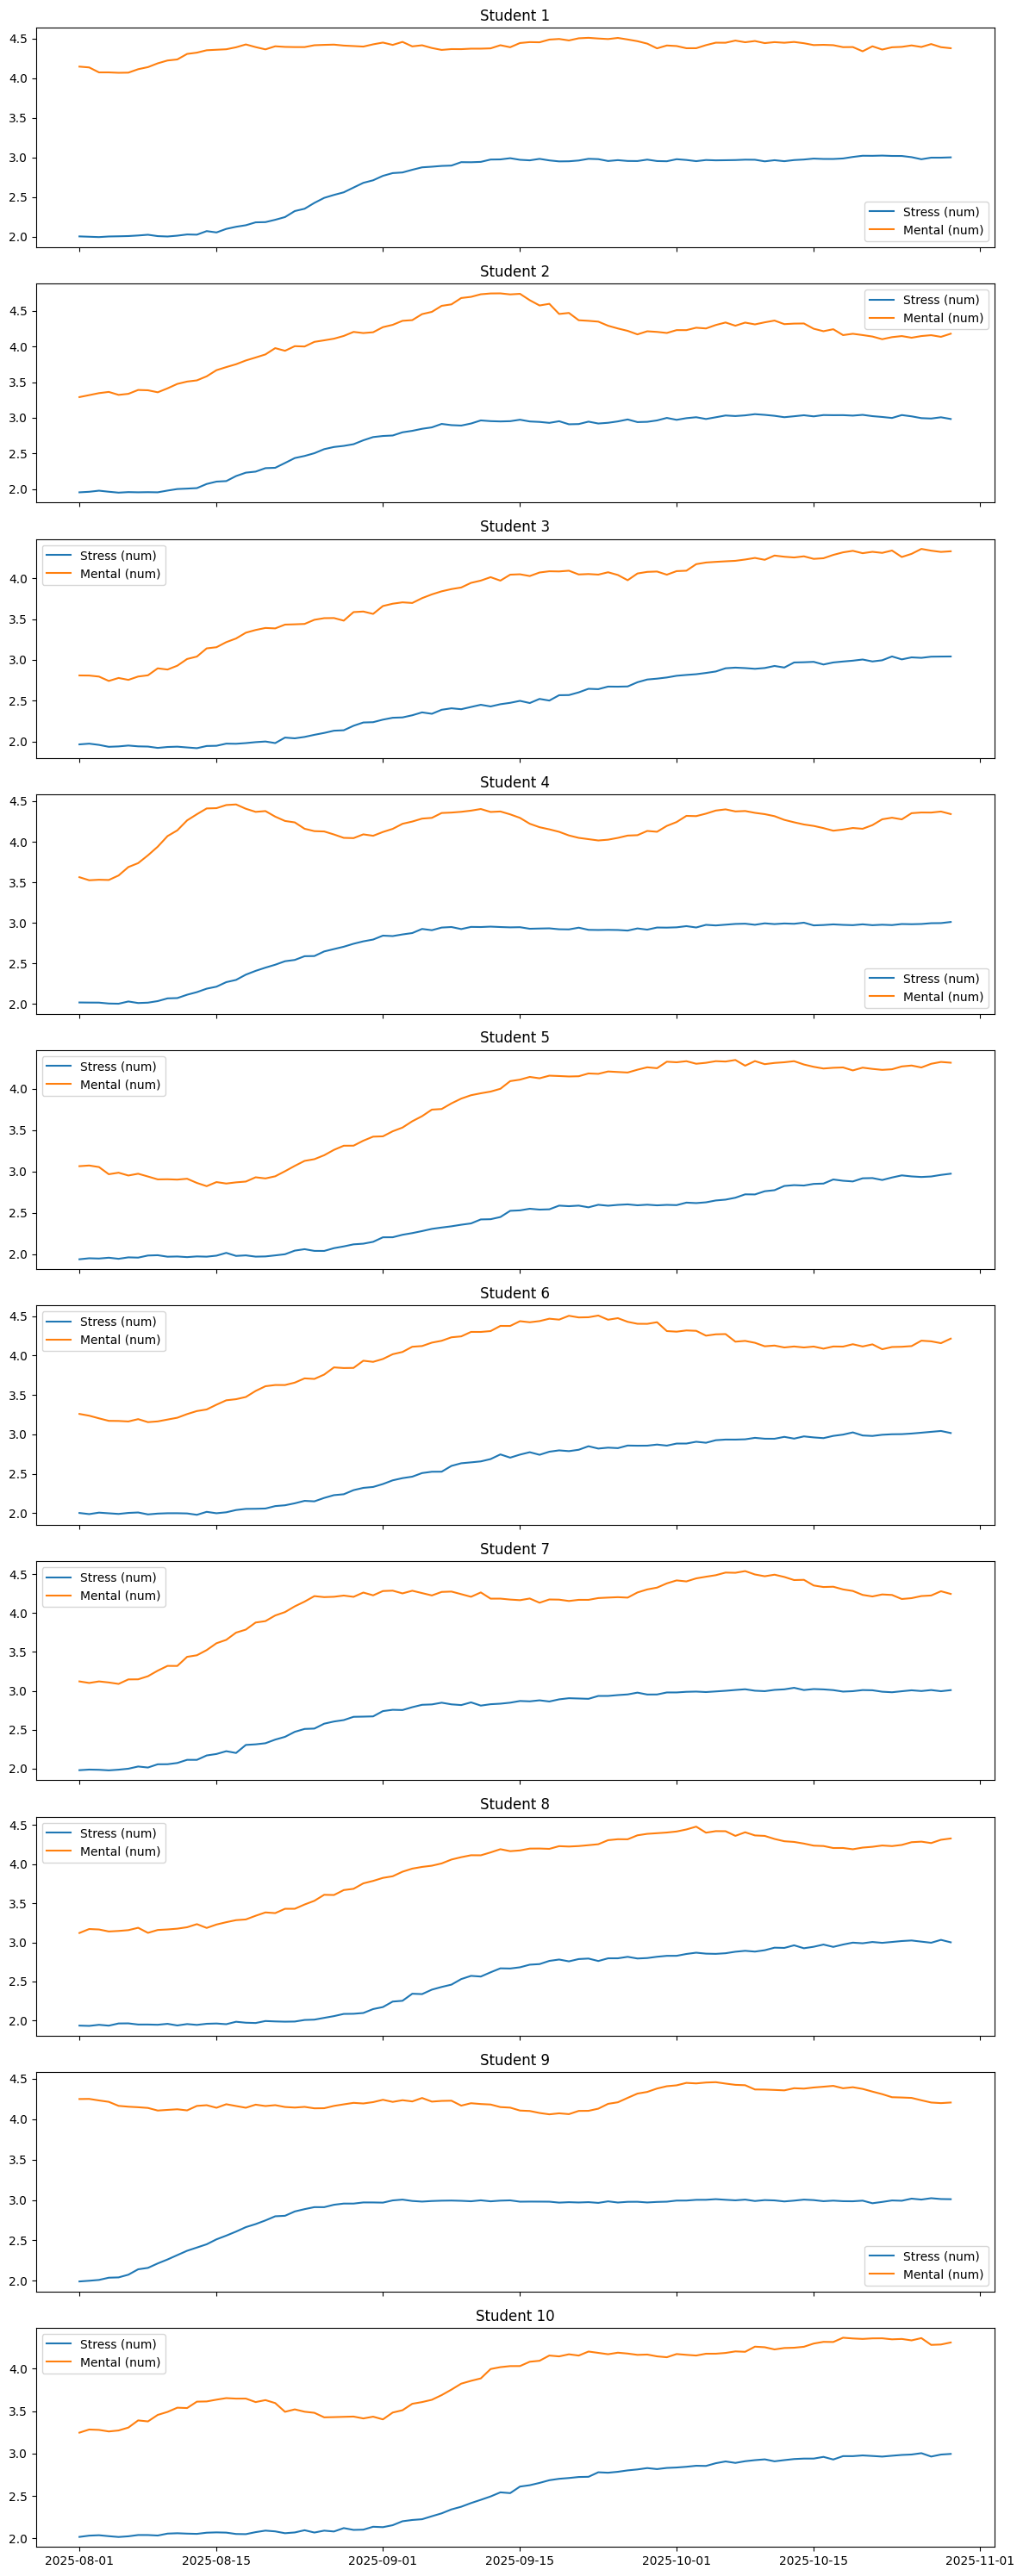

In [50]:
# %%
import matplotlib.pyplot as plt
import numpy as np
combined = pd.read_csv("newdata/forecast_outputs/all_students_3mo_forecasts.csv", parse_dates=['date'])
students = sorted(combined['StudentID'].unique())[:10]  # plot first 6
fig, axs = plt.subplots(len(students), 1, figsize=(12, 3*len(students)), sharex=True)
for i,sid in enumerate(students):
    sub = combined[combined['StudentID']==sid]
    axs[i].plot(sub['date'], sub['Stress_Level_Score'], label='Stress (num)')
    axs[i].plot(sub['date'], sub['Mental_Health_Status_Score'], label='Mental (num)')
    axs[i].set_title(f"Student {sid}")
    axs[i].legend()
plt.tight_layout()
plt.show()


In [51]:
# %%
import pandas as pd
labeled_dir = "newdata/forecast_outputs/per_student_labeled_3mo"
files = sorted([f for f in os.listdir(labeled_dir) if f.endswith('.csv')])
for f in files:
    df = pd.read_csv(os.path.join(labeled_dir,f), parse_dates=['date'])
    sid = f.split('_')[1]
    print(f"\n--- Student {sid} daily labels (first 7 rows) ---")
    for _, r in df.head(7).iterrows():
        print(f"{r['date'].date()} : {r['stress_pred_label']} | {r['mental_pred_label']}")



--- Student 10 daily labels (first 7 rows) ---
2025-08-01 : Medium | Moderate Stress
2025-08-02 : Medium | Moderate Stress
2025-08-03 : Medium | Moderate Stress
2025-08-04 : Medium | Moderate Stress
2025-08-05 : Medium | Moderate Stress
2025-08-06 : Medium | Moderate Stress
2025-08-07 : Medium | Moderate Stress

--- Student 1 daily labels (first 7 rows) ---
2025-08-01 : Medium | Depression
2025-08-02 : Medium | Depression
2025-08-03 : Medium | Depression
2025-08-04 : Medium | Depression
2025-08-05 : Medium | Depression
2025-08-06 : Medium | Depression
2025-08-07 : Medium | Depression

--- Student 2 daily labels (first 7 rows) ---
2025-08-01 : Medium | Moderate Stress
2025-08-02 : Medium | Moderate Stress
2025-08-03 : Medium | Moderate Stress
2025-08-04 : Medium | Moderate Stress
2025-08-05 : Medium | Moderate Stress
2025-08-06 : Medium | Moderate Stress
2025-08-07 : Medium | Moderate Stress

--- Student 3 daily labels (first 7 rows) ---
2025-08-01 : Medium | Moderate Stress
2025-08-02

In [52]:
# %%
import tensorflow as tf
from sklearn.metrics import mean_absolute_error
import joblib

model_path = "newdata/forecast_outputs/per_student_models/student_1_model.h5"  # example
scaler_X_path = "newdata/forecast_outputs/per_student_models/scaler_X_student_1.joblib"
scaler_y_path = "newdata/forecast_outputs/per_student_models/scaler_y_student_1.joblib"

model = tf.keras.models.load_model(model_path, compile=False)   # avoid deserialize metric objects
scaler_X_s = joblib.load(scaler_X_path)
scaler_y_s = joblib.load(scaler_y_path)

# prepare X_input same as training then predict, inverse transform, then compute MAE manually
# e.g.
# y_pred = model.predict(X_input); y_pred_inv = scaler_y_s.inverse_transform(y_pred.reshape(-1,n_targets)).reshape(...)
# mae = mean_absolute_error(y_true, y_pred_inv)


In [53]:
series = df_feat['Stress_Level_Score']


In [54]:
train_size = int(len(series) * 0.85)
train_series = series.iloc[:train_size]
val_series   = series.iloc[train_size:]


In [ ]:
# Naive forecast: last value
naive_forecast = np.repeat(train_series.iloc[-1], len(val_series))

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

naive_mae = mean_absolute_error(val_series, naive_forecast)
naive_rmse = np.sqrt(mean_squared_error(val_series, naive_forecast))


In [56]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train_series, order=(1,1,1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(val_series))

arima_mae = mean_absolute_error(val_series, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(val_series, arima_forecast))


In [57]:
lstm_mae  = metrics_global.loc[metrics_global['Split']=='Validation','MAE'].values[0]
lstm_rmse = metrics_global.loc[metrics_global['Split']=='Validation','RMSE'].values[0]


In [58]:
comparison_df = pd.DataFrame({
    "Model": ["Naive", "ARIMA", "LSTM"],
    "MAE": [naive_mae, arima_mae, lstm_mae],
    "RMSE": [naive_rmse, arima_rmse, lstm_rmse]
})

display(comparison_df)


,Model,MAE,RMSE
0,Naive,0.499655,0.659284
1,ARIMA,0.497837,0.655550
2,LSTM,0.098231,0.138699


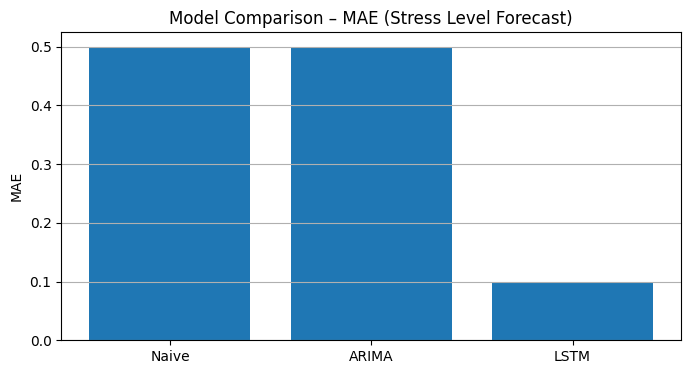

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(comparison_df["Model"], comparison_df["MAE"])
plt.title("Model Comparison – MAE (Stress Level Forecast)")
plt.ylabel("MAE")
plt.grid(axis='y')
plt.show()


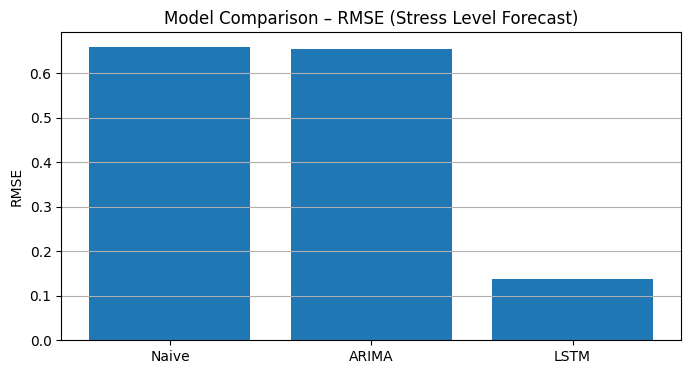

In [60]:
plt.figure(figsize=(8,4))
plt.bar(comparison_df["Model"], comparison_df["RMSE"])
plt.title("Model Comparison – RMSE (Stress Level Forecast)")
plt.ylabel("RMSE")
plt.grid(axis='y')
plt.show()
